# Ερώτημα 2 - Classification (CIC-IDS-2017)

**Στόχοι αυτού του notebook**

1. Φόρτωση του καθαρού, feature-selected dataset που παρήγαγε το Q1.
2. Encoding (LabelEncoder), scaling (StandardScaler μέσα σε Pipeline) και αντιμετώπιση του class imbalance με `class_weight='balanced'`.
3. Δύο πρωτόκολλα αξιολόγησης πάνω στο **ίδιο** test set:
   - **Σενάριο A** - stratified 60/20/20 train/validation/test split, hyperparameter selection με held-out validation.
   - **Σενάριο B** - 5-fold StratifiedKFold μέσω `GridSearchCV` πάνω στο 80% training, με ίδια test set.
4. Εκπαίδευση τριών αλγορίθμων με τα grids που ορίζει η εκφώνηση:
   - Logistic Regression
   - Decision Tree
   - Random Forest
5. Αξιολόγηση: Accuracy, Precision, Recall, F1-weighted, F1-macro, confusion matrix.
6. Συγκριτικός πίνακας 6 παραλλαγών (3 αλγόριθμοι × 2 σενάρια) και απάντηση των τεσσάρων ερωτήσεων που θέτει η εκφώνηση.

> **Σημείωση εκτέλεσης.** Το πλήρες cleaned dataset είναι ~2.5M γραμμές. Στο επόμενο cell ορίζεται η μεταβλητή `SUBSAMPLE_CAP` που ελέγχει πόσα rows θα χρησιμοποιηθούν. Οι μειονοτικές κλάσεις (Heartbleed=11, SQL Injection=21, Infiltration=36, ...) διατηρούνται *πλήρως* σε κάθε mode.

## 0. Imports και environment setup

In [1]:
import sys
import time
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Σιγάζουμε τα convergence warnings του LR με μικρά C/few iterations - τα
# βλέπουμε στο grid και είναι φυσιολογικά μέρος της αναζήτησης.
warnings.filterwarnings('ignore', message='.*did not converge.*')
warnings.filterwarnings('ignore', message='.*lbfgs failed to converge.*')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from utils import (
    RANDOM_STATE,
    load_clean_cached,
    evaluate_classifier,
    manual_grid_search,
    plot_confusion,
    plot_feature_importance,
    plot_lr_coefficients,
    plot_decision_tree,
    plot_one_forest_tree,
    save_figure,
    save_results,
)

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print('NumPy', np.__version__)
print('Pandas', pd.__version__)
import sklearn; print('scikit-learn', sklearn.__version__)
print('Random seed', RANDOM_STATE)


NumPy 2.4.4
Pandas 3.0.2
scikit-learn 1.8.0
Random seed 42


**Γιατί αυτά τα imports έχουν σημασία**

- **`Pipeline`** - δένει τον `StandardScaler` με τον classifier ώστε σε κάθε CV fold ή σε κάθε validation evaluation, ο scaler να γίνεται `fit` *μόνο* στα training data του εκάστοτε fold. Έτσι αποφεύγουμε **data leakage** (το να μάθει ο scaler μέσο/std από rows που αργότερα θα χρησιμοποιηθούν ως test).
- **`StratifiedKFold`** - σε σοβαρά imbalanced datasets όπως το CIC-IDS-2017, ένα απλό KFold μπορεί να βγάλει fold όπου μια rare κλάση (π.χ. Heartbleed=11 rows) δεν εμφανίζεται καθόλου - το stratified εξασφαλίζει ότι κάθε fold έχει αναλογικό αριθμό κάθε κλάσης.
- **`class_weight='balanced'`** - ζυγίζει το loss αντιστρόφως ανάλογα με τη συχνότητα κάθε κλάσης. Χωρίς αυτό, ένας classifier μπορεί να βγάλει ~80% accuracy απλώς προβλέποντας πάντα `BENIGN`.

## ⚙️ Configuration - επιλογή μεγέθους εκπαίδευσης

Η μεταβλητή `SUBSAMPLE_CAP` ορίζει πόσα rows ανά κλάση θα κρατήσουμε. Οι rare attacks (Heartbleed, SQL Injection, Infiltration, Web Attack XSS, Bot, ...) διατηρούνται **πάντα πλήρως** ανεξάρτητα από το cap - το cap ενεργοποιείται μόνο για τις τέσσερις τεράστιες κλάσεις (BENIGN, DoS Hulk, DDoS, PortScan).

| Mode    | `SUBSAMPLE_CAP` | Συνολικά rows | Αναμενόμενος χρόνος* | RAM | Συνιστάται για |
|---|---|---|---|---|---|
| **fast**   | `25_000`  | ~134K   | ~15-25 min  | ~2 GB    | iteration, debugging |
| **medium** | `100_000` | ~500K   | ~2-4 hours  | ~6 GB    | ισχυρότερα μετρικά |
| **full**   | `None`    | ~2.5M   | **~12+ hours** | ~16 GB | μόνο αν θέλουμε reference run |

*Εκτιμήσεις σε σύγχρονο laptop (8 cores). Το LR με solver `saga` σε full mode είναι το πιο αργό: μπορεί να χρειαστεί 1-3 hours ανά fit.

**Σύσταση**: αρχικά τρέξτε σε `fast` για να επαληθεύσετε ότι το pipeline δουλεύει· μετά ανεβάστε σε `medium` αν θέλετε πιο αξιόπιστα ranking μεταξύ μοντέλων.

In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  ΑΛΛΑΞΕ ΕΔΩ ΤΟ MODE                                              ║
# ║  fast   → SUBSAMPLE_CAP = 25_000   (~134K rows, ~15-25 min)      ║
# ║  medium → SUBSAMPLE_CAP = 100_000  (~500K rows, ~2-4 hours)      ║
# ║  full   → SUBSAMPLE_CAP = None     (~2.5M rows, ~12+ hours)      ║
# ╚══════════════════════════════════════════════════════════════════╝
SUBSAMPLE_CAP: int | None = 25_000

MODE_NAME = (
    'FULL DATASET'   if SUBSAMPLE_CAP is None
    else f'SUBSAMPLED with cap={SUBSAMPLE_CAP:,}'
)
print(f'Mode: {MODE_NAME}')


Mode: SUBSAMPLED with cap=25,000


## 2.1 Data preparation

Φορτώνουμε το cached Parquet που έγραψε το Q1 και το χωρίζουμε σε features `X` και target `y`.

In [3]:
df = load_clean_cached()
print(f'Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory : {df.memory_usage(deep=True).sum()/1e9:.2f} GB')

y_raw = df['Label']
X_raw = df.drop(columns=['Label'])
print(f'Features: {X_raw.shape[1]}')
print(f'Classes : {y_raw.nunique()}')
y_raw.value_counts()


Shape  : 2,572,640 rows × 48 columns
Memory : 0.57 GB
Features: 47


Classes : 15


Label
BENIGN                      2146899
DoS Hulk                     172846
DDoS                         128014
PortScan                      90694
DoS GoldenEye                 10286
FTP-Patator                    5931
DoS slowloris                  5385
DoS Slowhttptest               5228
SSH-Patator                    3219
Bot                            1948
Web Attack Brute Force         1470
Web Attack XSS                  652
Infiltration                     36
Web Attack Sql Injection         21
Heartbleed                       11
Name: count, dtype: int64

### LabelEncoder vs One-Hot - ποιο και γιατί

Η `Label` είναι **κατηγορική με πολλές κλάσεις** (15 attack types + BENIGN). Δύο επιλογές:

| Σχήμα | Που ταιριάζει | Γιατί όχι αλλιώς |
|---|---|---|
| **LabelEncoder** ✅ | για το **target** ενός multi-class classifier - sklearn θέλει integer labels `[0, 1, ..., C-1]` | δεν θα είχε νόημα να κάνουμε one-hot το target για μη-νευρωνικούς classifiers - θα γινόταν multi-output regression |
| **OneHotEncoder** | για **κατηγορικά features** (όχι target) | παράγει sparse matrix με μία στήλη ανά κλάση - δεν χρειάζεται για το `Label` |

Η σύμβαση είναι: LabelEncoder στο `y`, OneHotEncoder στα κατηγορικά `X`. Στο dataset μας όλα τα features είναι ήδη numeric, άρα μόνο το target χρειάζεται encoding.

In [4]:
le = LabelEncoder()
y_enc = le.fit_transform(y_raw)

label_map = pd.DataFrame({
    'class_id': range(len(le.classes_)),
    'label'   : le.classes_,
    'count'   : pd.Series(y_enc).value_counts().sort_index().values,
})
label_map['pct'] = (label_map['count'] / label_map['count'].sum() * 100).round(4)
save_results(label_map, 'q2_label_encoding.csv')
label_map


,class_id,label,count,pct
0,0,BENIGN,2146899,83.4512
1,1,Bot,1948,0.0757
2,2,DDoS,128014,4.9760
3,3,DoS GoldenEye,10286,0.3998
4,4,DoS Hulk,172846,6.7186
5,5,DoS Slowhttptest,5228,0.2032
6,6,DoS slowloris,5385,0.2093
7,7,FTP-Patator,5931,0.2305
8,8,Heartbleed,11,0.0004
9,9,Infiltration,36,0.0014


### Εφαρμογή του cap (ή full dataset)

Αν `SUBSAMPLE_CAP` είναι integer, κρατάμε `min(class_size, cap)` rows ανά κλάση, με την ίδια `random_state` για reproducibility. Οι rare κλάσεις (Heartbleed=11, SQL Injection=21, Infiltration=36, ...) διατηρούνται *πλήρως* - το cap κόβει μόνο τις τέσσερις τεράστιες.

**Γιατί όχι uniform random sample.** Ένα uniform 5% sample πάνω σε 2.5M rows θα έδινε Heartbleed ≈ 0-1 rows. Το per-class cap διατηρεί όλες τις rare attack classes.

**Καθαρός pre-split χειρισμός.** Το subsampling γίνεται *πριν* το train/test split ώστε και τα δύο σενάρια A και B να βλέπουν ακριβώς το ίδιο dataset.

**Imbalance που μένει.** Σε `cap=25K`: 25K BENIGN vs 11 Heartbleed → ratio ~2,272:1. Σε `cap=None` (full): 2.14M BENIGN vs 11 Heartbleed → ratio ~195K:1. Σε κάθε περίπτωση το `class_weight='balanced'` και η παρακολούθηση F1-macro παραμένουν αναγκαία.

In [5]:
rng = np.random.default_rng(RANDOM_STATE)

if SUBSAMPLE_CAP is None:
    # Full dataset - no subsampling
    X = X_raw.reset_index(drop=True)
    y = y_enc.copy()
else:
    keep_idx = []
    for cls in np.unique(y_enc):
        cls_idx = np.where(y_enc == cls)[0]
        if len(cls_idx) > SUBSAMPLE_CAP:
            cls_idx = rng.choice(cls_idx, size=SUBSAMPLE_CAP, replace=False)
        keep_idx.append(cls_idx)
    keep_idx = np.sort(np.concatenate(keep_idx))
    X = X_raw.iloc[keep_idx].reset_index(drop=True)
    y = y_enc[keep_idx]

print(f'Mode    : {MODE_NAME}')
print(f'Original: {len(y_enc):,} rows')
print(f'Active  : {len(y):,} rows  ({len(y)/len(y_enc)*100:.2f}% του original)')
print()

sample_dist = pd.DataFrame({
    'class_id': range(len(le.classes_)),
    'label'   : le.classes_,
    'original': pd.Series(y_enc).value_counts().sort_index().values,
    'active'  : pd.Series(y).value_counts().sort_index()
                  .reindex(range(len(le.classes_)), fill_value=0).values,
})
sample_dist['ratio'] = (sample_dist['active'] / sample_dist['original'] * 100).round(2)
save_results(sample_dist, 'q2_subsample_distribution.csv')
sample_dist


Mode    : SUBSAMPLED with cap=25,000
Original: 2,572,640 rows
Active  : 134,187 rows  (5.22% του original)



,class_id,label,original,active,ratio
0,0,BENIGN,2146899,25000,1.1600
1,1,Bot,1948,1948,100.0000
2,2,DDoS,128014,25000,19.5300
3,3,DoS GoldenEye,10286,10286,100.0000
4,4,DoS Hulk,172846,25000,14.4600
5,5,DoS Slowhttptest,5228,5228,100.0000
6,6,DoS slowloris,5385,5385,100.0000
7,7,FTP-Patator,5931,5931,100.0000
8,8,Heartbleed,11,11,100.0000
9,9,Infiltration,36,36,100.0000


### Στρατηγικές imbalance handling

| Στρατηγική | Που εφαρμόζεται | Σχόλιο |
|---|---|---|
| **`class_weight='balanced'`** ✅ | LR, DT, RF (όλα τα στηρίζουν) | δεν αλλάζει τα δεδομένα, αλλάζει το loss/criterion - ζυγίζει κάθε row με `n_samples / (n_classes * count[class])` |
| **SMOTE / oversampling** | πριν το fit | δημιουργεί συνθετικά rows για τις rare κλάσεις - κίνδυνος leakage αν δεν εφαρμοστεί ανά CV fold |
| **Random undersampling** | πριν το fit | πετάει BENIGN rows - ήδη το κάναμε εν μέρει αν `SUBSAMPLE_CAP` είναι μικρό |

Επιλέξαμε **`class_weight='balanced'`** ως πιο καθαρή και χωρίς κίνδυνο leakage λύση. Είναι η συνιστώμενη πρώτη γραμμή άμυνας για multi-class imbalanced classification.

### Stratified 60/20/20 split

Σε δύο βήματα:
1. Πρώτα 80/20 → `trainval` / `test`. Το `test` είναι ο τυφλός μάρτυρας: το αγγίζουμε *μόνο* στο τέλος.
2. Από το `trainval` σπάμε 75/25 → `train` / `val` (το οποίο δίνει 60/20 του original).

**Γιατί stratified.** Χωρίς stratify, η Heartbleed (11 rows) μπορεί να βρεθεί 0/0/11 ή 11/0/0 - ο classifier δεν θα τη μάθει. Με stratify, sklearn φροντίζει η αναλογία κάθε κλάσης να διατηρείται *προσεγγιστικά* σε κάθε split (round-up/down για μικρά counts).

**Πρωτόκολλο σε όλο το Q2.**
- **Σενάριο A** - manual grid search: για κάθε combo, fit στο `train`, eval στο `val`. Επιλέγουμε best params, refit στο `trainval`, eval στο `test`.
- **Σενάριο B** - `GridSearchCV(cv=StratifiedKFold(5))` πάνω στο `trainval`. Επιλέγουμε best params, eval στο `test`.

Και τα δύο σενάρια *χρησιμοποιούν το ίδιο test set* - μόνο έτσι έχουν νόημα οι μεταξύ τους συγκρίσεις.

In [6]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25,
    stratify=y_trainval, random_state=RANDOM_STATE,
)

print(f'train    : {X_train.shape[0]:>7,} rows  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'val      : {X_val.shape[0]:>7,} rows  ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'test     : {X_test.shape[0]:>7,} rows  ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'trainval : {X_trainval.shape[0]:>7,} rows  ({X_trainval.shape[0]/len(X)*100:.1f}%)')


train    :  80,511 rows  (60.0%)
val      :  26,838 rows  (20.0%)
test     :  26,838 rows  (20.0%)
trainval : 107,349 rows  (80.0%)


In [7]:
# Επαλήθευση ότι όλες οι κλάσεις παρουσιάζονται και στα 3 splits.
split_check = pd.DataFrame({
    'label'   : le.classes_,
    'train'   : pd.Series(y_train).value_counts().reindex(range(len(le.classes_)), fill_value=0).values,
    'val'     : pd.Series(y_val).value_counts().reindex(range(len(le.classes_)), fill_value=0).values,
    'test'    : pd.Series(y_test).value_counts().reindex(range(len(le.classes_)), fill_value=0).values,
})
save_results(split_check, 'q2_split_distribution.csv')
split_check


,label,train,val,test
0,BENIGN,15000,5000,5000
1,Bot,1168,390,390
2,DDoS,15000,5000,5000
3,DoS GoldenEye,6171,2058,2057
4,DoS Hulk,15000,5000,5000
5,DoS Slowhttptest,3136,1046,1046
6,DoS slowloris,3231,1077,1077
7,FTP-Patator,3559,1186,1186
8,Heartbleed,7,2,2
9,Infiltration,22,7,7


**Πρακτικός έλεγχος (fast mode, `SUBSAMPLE_CAP=25_000`).** Το splitting παρήγαγε `train=80,511 / val=26,838 / test=26,838` (60/20/20). Όλες οι 15 κλάσεις παρουσιάζονται και στα τρία splits. Για τις τέσσερις τεράστιες κλάσεις (BENIGN, DDoS, DoS Hulk, PortScan) έχουμε 15,000 / 5,000 / 5,000 ανά split. Για τις πιο σπάνιες όμως τα νούμερα είναι οριακά: **Heartbleed → 7/2/2**, **SQL Injection → 13/4/4**, **Infiltration → 22/7/7**. Με τόσο λίγα test rows, ένα-δύο λάθη ρίχνουν το per-class F1 αυτής της κλάσης σε 0, οπότε το F1-macro θα έχει υψηλή variance - κάτι που θα δούμε στη συγκριτική ανάλυση.

## Evaluation helpers - όλα έρχονται από το `utils`

Τα παρακάτω εργαλεία ζουν στο `utils.helpers` (re-exported από το `utils` package) ώστε να παραμένουν reusable για το Q3 και να μην χρειάζεται να τα ξανα-ορίζουμε σε κάθε notebook:

| Helper | Τι κάνει |
|---|---|
| `evaluate_classifier(y_true, y_pred)` | επιστρέφει dict με Accuracy, Precision (weighted), Recall (weighted), F1-weighted, F1-macro |
| `manual_grid_search(make_est, grid, X_tr, y_tr, X_va, y_va)` | Σενάριο A: full sweep πάνω σε `grid`, scoring με F1-weighted στο held-out validation |
| `plot_confusion(y_true, y_pred, labels, title, fname)` | row-normalized confusion matrix heatmap, αποθηκευμένο στο `outputs/figures/` |
| `plot_feature_importance(model, feature_names, top_k, title, fname)` | horizontal bar chart των κορυφαίων feature importances |

**Γιατί F1-weighted ως scoring** για την επιλογή hyperparameters:
- **Accuracy** εξαπατά σε imbalanced multi-class (~80% απλώς από το να προβλέπει BENIGN πάντα).
- **F1-macro** δίνει ίσο βάρος σε κάθε κλάση - σωστό αν θέλουμε rare-attack recall, αλλά οι rare κλάσεις (Heartbleed=11 rows) έχουν τέτοια variance που dominate τη μετρική κατά την επιλογή.
- **F1-weighted** ζυγίζει κάθε κλάση με τη support της και είναι το default του scikit-learn σε multi-class problems. Σταθερότερη μετρική για hyperparameter selection.

Στο **final reporting** δείχνουμε *και τα δύο* (weighted + macro) ώστε να φανεί αν το μοντέλο είναι «cheap» (καλό weighted αλλά κακό macro = αγνοεί τις rare attacks).

**Σχεδιαστική σημείωση για το `manual_grid_search`.** Καλεί `make_est()` (factory χωρίς params) και μετά `est.set_params(**combo)`. Έτσι το ίδιο API δουλεύει είτε το `make_est` επιστρέφει plain estimator (DT/RF, με keys όπως `max_depth`) είτε `Pipeline` (LR, με keys όπως `algo__C`).

## 2.2 Algorithm 1 - Logistic Regression

**Διαίσθηση.** Παρά το «regression» στο όνομα, η Logistic Regression είναι classifier. Σε ένα binary πρόβλημα, υπολογίζει ένα γραμμικό συνδυασμό των features και τον περνά μέσα από τη **sigmoid** για να βγάλει πιθανότητα. Σε multi-class ((n>2)), το sklearn χρησιμοποιεί **softmax** (multinomial LR): μία γραμμική συνάρτηση ανά κλάση, normalized έτσι ώστε να δίνουν probabilities που αθροίζουν σε 1.

**Decision boundary** - υπερεπίπεδα στον feature space. Ο χωρισμός των κλάσεων γίνεται με *ευθείες* (hyperplanes σε υψηλότερες διαστάσεις).

**Γιατί καλό baseline.** Είναι ταχύτατο, ερμηνεύσιμο (συντελεστές ανά feature), δίνει calibrated probabilities, και σε γραμμικά διαχωρίσιμα προβλήματα είναι αρκετό. Όταν δεν είναι αρκετό, μας λέει «το πρόβλημα δεν είναι γραμμικό».

**Περιορισμοί στο CIC-IDS-2017.**
- Υποθέτει γραμμική σχέση features → log-odds. Πολλά network features (rates, IAT) έχουν πολύ skewed κατανομές οπότε αυτή η υπόθεση είναι αμφίβολη.
- Ευαίσθητο σε scale (γι' αυτό κάνουμε `StandardScaler`).
- Δεν πιάνει συνδυαστικές αλληλεπιδράσεις features (π.χ. «μικρό packet *και* υψηλό SYN count») παρά μόνο αν τις προσθέσουμε χειροκίνητα.

**Hyperparameter grid (όπως ορίζει η εκφώνηση).**
- `C ∈ {0.01, 0.1, 1, 10}` - inverse regularization. Μικρό `C` = ισχυρό L2 = πιο smooth boundary.
- `solver ∈ {lbfgs, saga}` - lbfgs είναι quasi-Newton, γρήγορος σε small/medium data· saga είναι stochastic, scaling-friendly.
- `max_iter ∈ {200, 500}` - πόσες επαναλήψεις πριν δηλώσει non-convergence.


In [8]:
LR_GRID = {
    'algo__C'        : [0.01, 0.1, 1, 10],
    'algo__solver'   : ['lbfgs', 'saga'],
    'algo__max_iter' : [200, 500],
}

def make_lr_pipeline() -> Pipeline:
    """Fresh scaler+LR pipeline. Hyperparams εφαρμόζονται μέσω `set_params(**combo)`
    ώστε το `algo__C` prefix να φτάνει στο σωστό step του Pipeline."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('algo'  , LogisticRegression(
            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])

print(f'LR grid combos: {len(LR_GRID["algo__C"]) * len(LR_GRID["algo__solver"]) * len(LR_GRID["algo__max_iter"])}')


LR grid combos: 16


### LR - Σενάριο A (60/20/20 split, validation-based selection)

In [9]:
t0 = time.time()
lr_A_best, lr_A_score, lr_A_grid = manual_grid_search(
    make_lr_pipeline, LR_GRID, X_train, y_train, X_val, y_val,
)
save_results(lr_A_grid, 'q2_lr_grid_A.csv')
print(f'Best params (val F1-weighted = {lr_A_score:.4f}):')
for k, v in lr_A_best.items():
    print(f'  {k} = {v}')
print(f'\nGrid search time: {time.time()-t0:.1f}s')
lr_A_grid.head(10)


D:\Documents\GitHub\network-intrusion-detection-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


D:\Documents\GitHub\network-intrusion-detection-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


D:\Documents\GitHub\network-intrusion-detection-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


D:\Documents\GitHub\network-intrusion-detection-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


D:\Documents\GitHub\network-intrusion-detection-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


...

D:\Documents\GitHub\network-intrusion-detection-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


D:\Documents\GitHub\network-intrusion-detection-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


D:\Documents\GitHub\network-intrusion-detection-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Best params (val F1-weighted = 0.9611):
  algo__C = 10
  algo__solver = lbfgs
  algo__max_iter = 500

Grid search time: 677.8s


,algo__C,algo__solver,algo__max_iter,val_f1_weighted
0,10.0000,lbfgs,500,0.9611
1,10.0000,lbfgs,200,0.9591
2,1.0000,lbfgs,500,0.9525
3,1.0000,lbfgs,200,0.9511
4,0.1000,lbfgs,200,0.9278
5,0.1000,lbfgs,500,0.9277
6,1.0000,saga,500,0.9116
7,10.0000,saga,500,0.9115
8,0.1000,saga,500,0.9109
9,0.0100,lbfgs,200,0.9066


In [10]:
# Refit στο trainval (train+val), eval στο test.
lr_A_final = make_lr_pipeline()
lr_A_final.set_params(**lr_A_best)
lr_A_final.fit(X_trainval, y_trainval)
lr_A_pred = lr_A_final.predict(X_test)
lr_A_metrics = evaluate_classifier(y_test, lr_A_pred)
print('LR Σενάριο A - test metrics:')
for k, v in lr_A_metrics.items():
    print(f'  {k:<14}: {v:.4f}')


D:\Documents\GitHub\network-intrusion-detection-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LR Σενάριο A - test metrics:
  accuracy      : 0.9595
  precision_w   : 0.9750
  recall_w      : 0.9595
  f1_weighted   : 0.9647
  f1_macro      : 0.7810


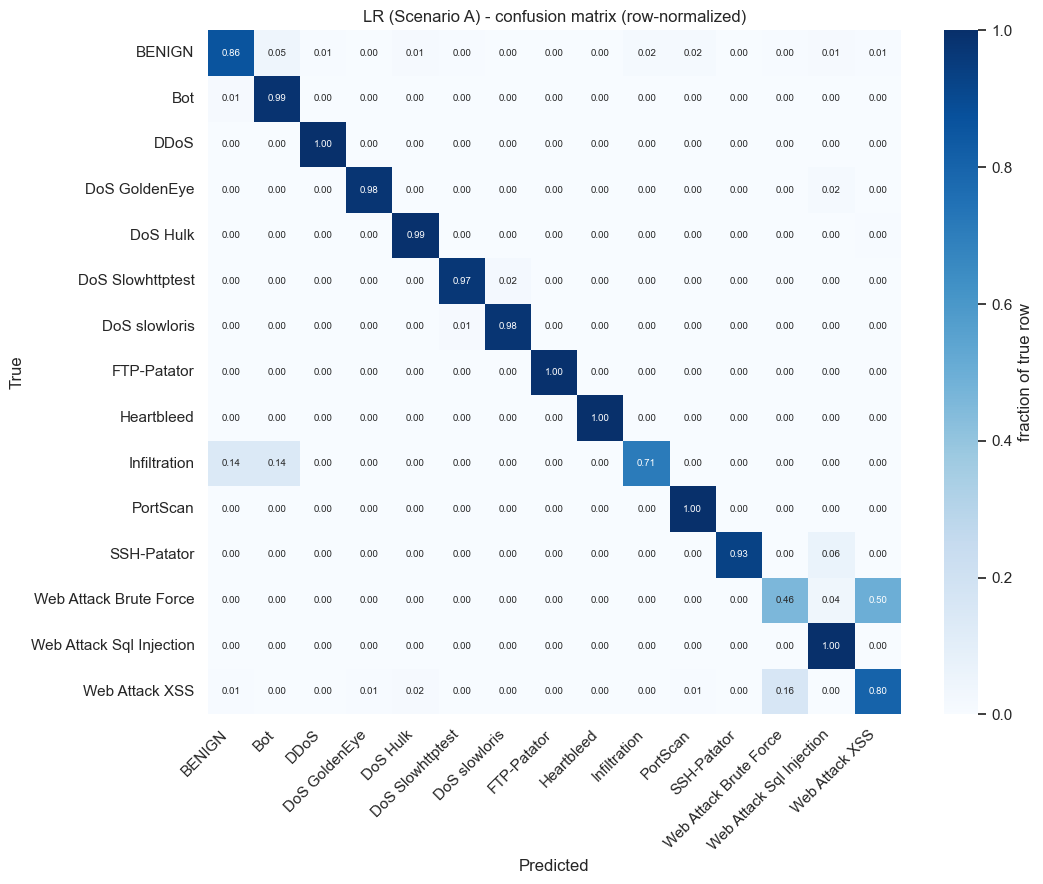

In [11]:
_ = plot_confusion(y_test, lr_A_pred, labels=list(le.classes_),
                   title='LR (Scenario A) - confusion matrix (row-normalized)',
                   fname='q2_lr_A_confusion.png')


### LR - Σενάριο B (5-fold StratifiedKFold μέσω GridSearchCV)

Ίδιο grid, ίδιο data (το ίδιο 80% trainval), αλλά διαφορετικό πρωτόκολλο: ο μέσος όρος F1-weighted πάνω σε 5 folds επιλέγει best params αντί για ένα μεμονωμένο validation set.

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

t0 = time.time()
lr_B_search = GridSearchCV(
    estimator=make_lr_pipeline(),
    param_grid=LR_GRID,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1,
    refit=True,
    verbose=0,
)
lr_B_search.fit(X_trainval, y_trainval)
print(f'Best params (mean CV F1-weighted = {lr_B_search.best_score_:.4f}):')
for k, v in lr_B_search.best_params_.items():
    print(f'  {k} = {v}')
print(f'\nCV grid search time: {time.time()-t0:.1f}s')

lr_B_grid_df = pd.DataFrame(lr_B_search.cv_results_)[
    ['param_algo__C','param_algo__solver','param_algo__max_iter',
     'mean_test_score','std_test_score','rank_test_score']
].sort_values('rank_test_score')
save_results(lr_B_grid_df.reset_index(drop=True), 'q2_lr_grid_B.csv')
lr_B_grid_df.head(10)


D:\Documents\GitHub\network-intrusion-detection-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Best params (mean CV F1-weighted = 0.9633):
  algo__C = 10
  algo__max_iter = 500
  algo__solver = lbfgs

CV grid search time: 828.9s


,param_algo__C,param_algo__solver,param_algo__max_iter,mean_test_score,std_test_score,rank_test_score
14,10.0000,lbfgs,500,0.9633,0.0011,1
12,10.0000,lbfgs,200,0.9604,0.0016,2
10,1.0000,lbfgs,500,0.9529,0.0013,3
8,1.0000,lbfgs,200,0.9520,0.0021,4
6,0.1000,lbfgs,500,0.9282,0.0019,5
4,0.1000,lbfgs,200,0.9280,0.0019,6
15,10.0000,saga,500,0.9114,0.0025,7
11,1.0000,saga,500,0.9113,0.0024,8
7,0.1000,saga,500,0.9103,0.0022,9
0,0.0100,lbfgs,200,0.9063,0.0017,10


LR Σενάριο B - test metrics:
  accuracy      : 0.9595
  precision_w   : 0.9750
  recall_w      : 0.9595
  f1_weighted   : 0.9647
  f1_macro      : 0.7810


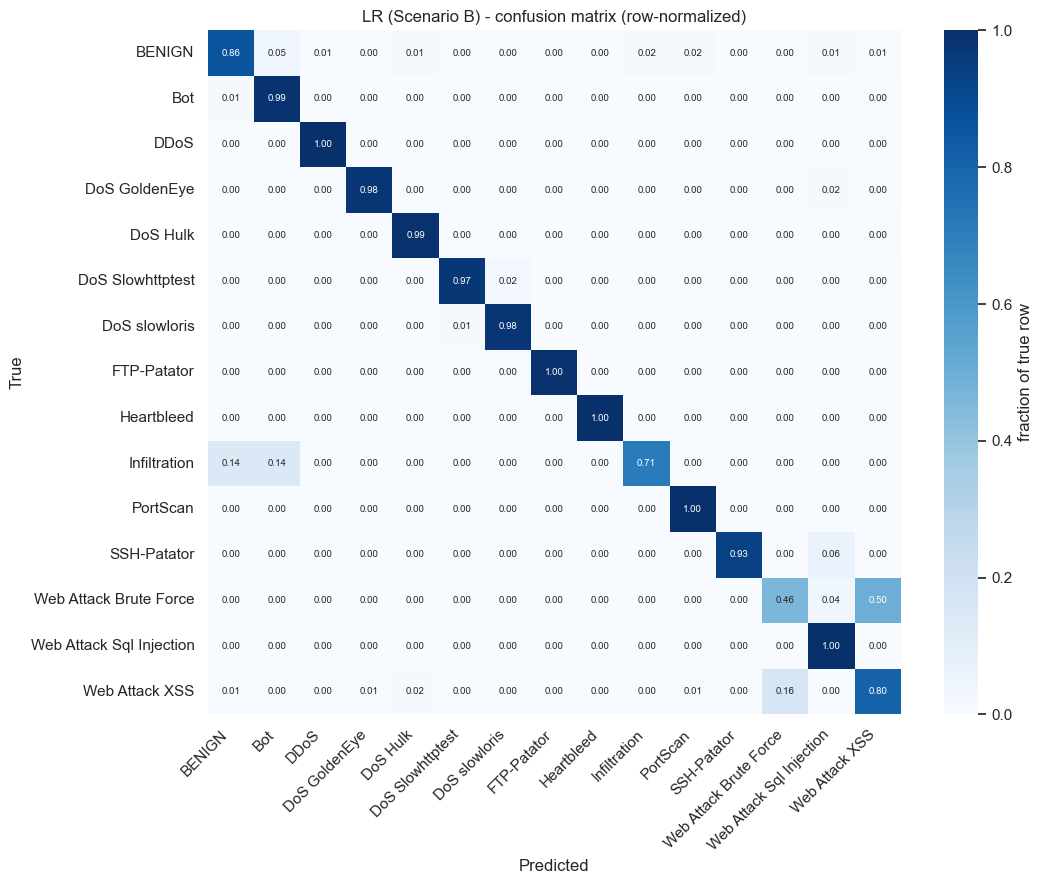

In [13]:
lr_B_pred = lr_B_search.best_estimator_.predict(X_test)
lr_B_metrics = evaluate_classifier(y_test, lr_B_pred)
print('LR Σενάριο B - test metrics:')
for k, v in lr_B_metrics.items():
    print(f'  {k:<14}: {v:.4f}')
_ = plot_confusion(y_test, lr_B_pred, labels=list(le.classes_),
                   title='LR (Scenario B) - confusion matrix (row-normalized)',
                   fname='q2_lr_B_confusion.png')


### LR - Visualization των συντελεστών

Στο multinomial LR ο πίνακας συντελεστών έχει shape `(n_classes, n_features)`. Κάθε row λέει πόσο σπρώχνει κάθε feature ένα sample *προς* (θετικό) ή *μακριά από* (αρνητικό) αυτή τη class. Εδώ δείχνουμε τα top-15 features κατά μέσο `|coefficient|` σε όλες τις κλάσεις.

**Πώς διαβάζεται το heatmap.**
- **Έντονο κόκκινο** (μεγάλος θετικός συντελεστής) = αυτό το feature οδηγεί strongly προς αυτή την κλάση.
- **Έντονο μπλε** (μεγάλος αρνητικός) = το feature *αντενδείκνυται* για αυτή την κλάση.
- **Λευκό** (~0) = το feature δεν επηρεάζει αυτή τη class στο LR.

Σε contrast με το tree-based feature importance, οι LR συντελεστές δίνουν *direction*, όχι μόνο magnitude. Αυτό είναι το «ερμηνεύσιμο» πλεονέκτημα του LR.

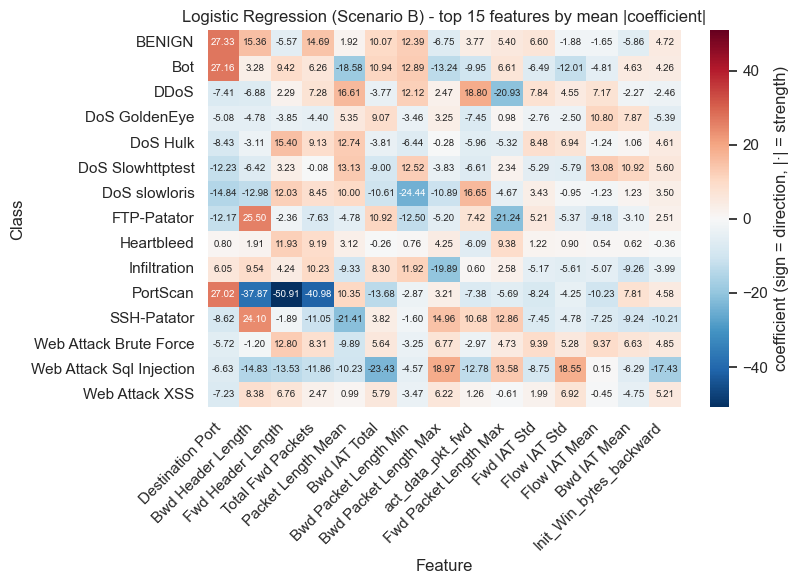

In [14]:
lr_estimator = lr_B_search.best_estimator_.named_steps['algo']
_ = plot_lr_coefficients(
    lr_estimator,
    feature_names=X_trainval.columns,
    class_names=le.classes_,
    top_k=15,
    title='Logistic Regression (Scenario B) - top 15 features by mean |coefficient|',
    fname='q2_lr_coefficients.png',
)


## 2.3 Algorithm 2 - Decision Tree

**Διαίσθηση.** Ένα δέντρο απόφασης είναι μια ακολουθία `if/else` ερωτήσεων πάνω στα features. Σε κάθε εσωτερικό κόμβο, ο αλγόριθμος επιλέγει το feature και το threshold που κάνει το καλύτερο **split** - δηλαδή χωρίζει το data σε δύο υποσύνολα όσο το δυνατόν πιο «καθαρά» από την οπτική των κλάσεων.

**Πώς μετράμε καθαρότητα.**
- **Gini impurity**: (1 - \sum_c p_c^2). Πιθανότητα να ταξινομήσεις λάθος μια τυχαία row αν τη βάλεις στο πιο συχνό class.
- **Entropy**: (-\sum_c p_c \log_2 p_c). Information theory measure - πόσα bits χρειάζονται για να κωδικοποιήσεις την κλάση.
- Στην πράξη Gini και Entropy δίνουν παραπλήσια trees - η εκφώνηση μας ζητά να συγκρίνουμε.

**Information gain** - η μείωση impurity που πετυχαίνει το split. Ο αλγόριθμος επιλέγει το split με το μέγιστο gain.

**Overfitting σε trees.** Ένα unbounded tree μπορεί να φτάσει σε *τέλεια* training accuracy δημιουργώντας έναν leaf για κάθε row. Αυτό είναι κλασικό overfitting: training perfect, test κακό. Δύο ρυθμίσεις regularization:
- `max_depth` - πάνω όριο βάθους (ρηχό δέντρο = λιγότερη χωρητικότητα).
- `min_samples_split` - κάτω όριο μεγέθους κόμβου ώστε να επιτρέπεται split (μεγάλο = πιο conservative).

**Δεν χρειάζεται scaling.** Τα splits είναι invariant σε monotonic transforms του feature - δεν έχει σημασία αν δουλεύουμε σε bytes ή MB.

**Hyperparameter grid (όπως ορίζει η εκφώνηση).**
- `max_depth ∈ {5, 10, 20, None}` - None = δεν υπάρχει όριο.
- `min_samples_split ∈ {2, 10, 50}` - default 2 = θα χωρίζει αν >= 2 samples.
- `criterion ∈ {gini, entropy}`.

In [15]:
DT_GRID = {
    'max_depth'         : [5, 10, 20, None],
    'min_samples_split' : [2, 10, 50],
    'criterion'         : ['gini', 'entropy'],
}

def make_dt() -> DecisionTreeClassifier:
    return DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)

print(f'DT grid combos: {len(DT_GRID["max_depth"]) * len(DT_GRID["min_samples_split"]) * len(DT_GRID["criterion"])}')


DT grid combos: 24


### DT - Σενάριο A (60/20/20 split, validation-based selection)

In [16]:
t0 = time.time()
dt_A_best, dt_A_score, dt_A_grid = manual_grid_search(
    make_dt, DT_GRID, X_train, y_train, X_val, y_val,
)
save_results(dt_A_grid, 'q2_dt_grid_A.csv')
print(f'Best params (val F1-weighted = {dt_A_score:.4f}):')
for k, v in dt_A_best.items():
    print(f'  {k} = {v}')
print(f'\nGrid search time: {time.time()-t0:.1f}s')
dt_A_grid.head(10)


Best params (val F1-weighted = 0.9914):
  max_depth = 20
  min_samples_split = 10
  criterion = entropy

Grid search time: 34.7s


,max_depth,min_samples_split,criterion,val_f1_weighted
0,20.0000,10,entropy,0.9914
1,20.0000,2,entropy,0.9914
2,NaN,10,entropy,0.9913
3,NaN,2,entropy,0.9913
4,NaN,2,gini,0.9908
5,NaN,10,gini,0.9903
6,20.0000,2,gini,0.9900
7,20.0000,10,gini,0.9896
8,NaN,50,entropy,0.9883
9,20.0000,50,entropy,0.9883


DT Σενάριο A - test metrics:
  accuracy      : 0.9918
  precision_w   : 0.9930
  recall_w      : 0.9918
  f1_weighted   : 0.9920
  f1_macro      : 0.9093


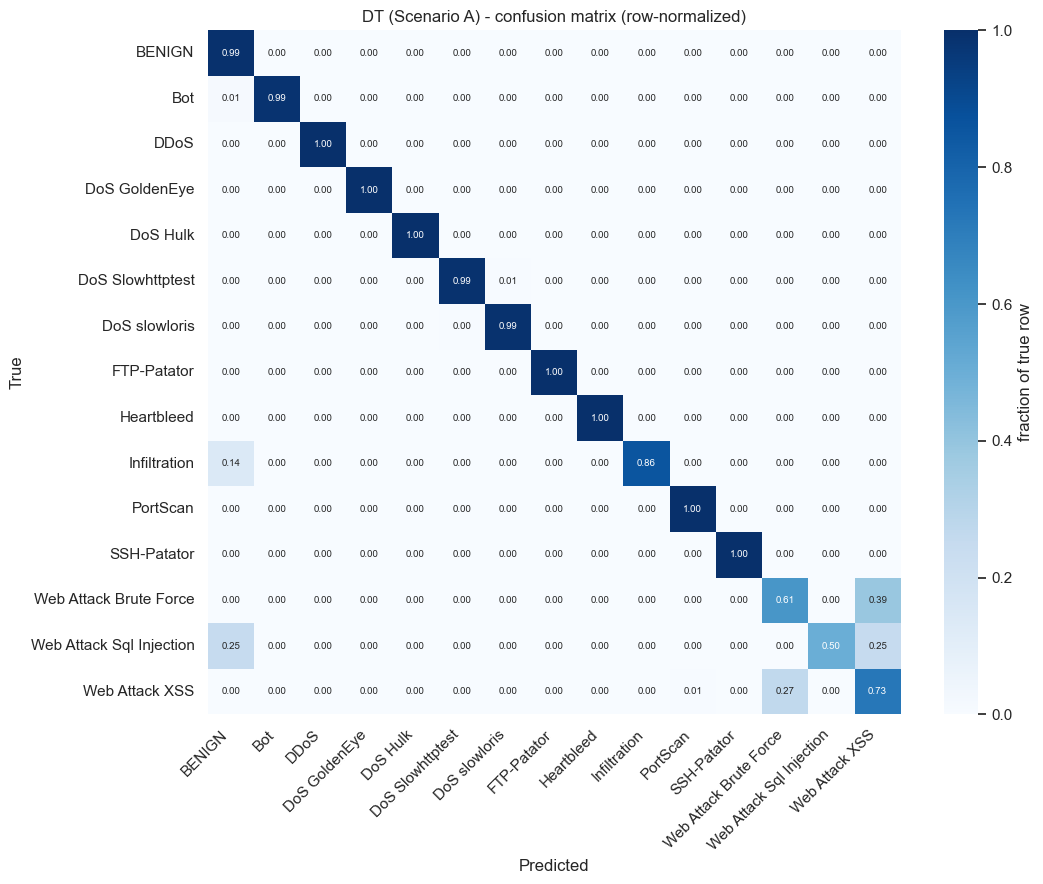

In [17]:
dt_A_final = make_dt()
dt_A_final.set_params(**dt_A_best)
dt_A_final.fit(X_trainval, y_trainval)
dt_A_pred = dt_A_final.predict(X_test)
dt_A_metrics = evaluate_classifier(y_test, dt_A_pred)
print('DT Σενάριο A - test metrics:')
for k, v in dt_A_metrics.items():
    print(f'  {k:<14}: {v:.4f}')
_ = plot_confusion(y_test, dt_A_pred, labels=list(le.classes_),
                   title='DT (Scenario A) - confusion matrix (row-normalized)',
                   fname='q2_dt_A_confusion.png')


### DT - Σενάριο B (5-fold CV)

In [18]:
t0 = time.time()
dt_B_search = GridSearchCV(
    estimator=make_dt(),
    param_grid=DT_GRID,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1,
    refit=True,
)
dt_B_search.fit(X_trainval, y_trainval)
print(f'Best params (mean CV F1-weighted = {dt_B_search.best_score_:.4f}):')
for k, v in dt_B_search.best_params_.items():
    print(f'  {k} = {v}')
print(f'\nCV grid search time: {time.time()-t0:.1f}s')

dt_B_grid_df = pd.DataFrame(dt_B_search.cv_results_)[
    ['param_max_depth','param_min_samples_split','param_criterion',
     'mean_test_score','std_test_score','rank_test_score']
].sort_values('rank_test_score')
save_results(dt_B_grid_df.reset_index(drop=True), 'q2_dt_grid_B.csv')
dt_B_grid_df.head(10)


Best params (mean CV F1-weighted = 0.9918):
  criterion = entropy
  max_depth = None
  min_samples_split = 2

CV grid search time: 44.9s


,param_max_depth,param_min_samples_split,param_criterion,mean_test_score,std_test_score,rank_test_score
21,None,2,entropy,0.9918,0.0008,1
22,None,10,entropy,0.9915,0.0008,2
18,20,2,entropy,0.9912,0.0008,3
9,None,2,gini,0.9911,0.0007,4
19,20,10,entropy,0.9910,0.0008,5
6,20,2,gini,0.9905,0.0008,6
10,None,10,gini,0.9903,0.0008,7
7,20,10,gini,0.9899,0.0007,8
23,None,50,entropy,0.9886,0.0012,9
20,20,50,entropy,0.9885,0.0011,10


DT Σενάριο B - test metrics:
  accuracy      : 0.9921
  precision_w   : 0.9920
  recall_w      : 0.9921
  f1_weighted   : 0.9920
  f1_macro      : 0.9097


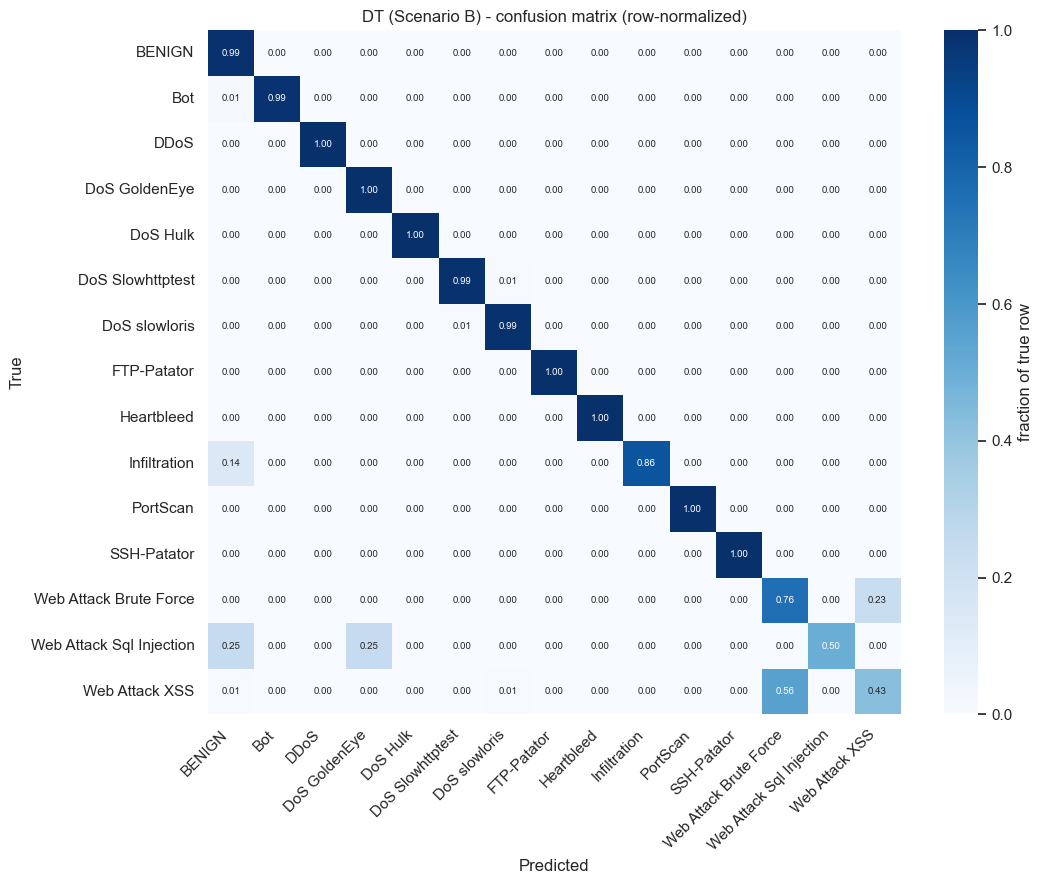

In [19]:
dt_B_pred = dt_B_search.best_estimator_.predict(X_test)
dt_B_metrics = evaluate_classifier(y_test, dt_B_pred)
print('DT Σενάριο B - test metrics:')
for k, v in dt_B_metrics.items():
    print(f'  {k:<14}: {v:.4f}')
_ = plot_confusion(y_test, dt_B_pred, labels=list(le.classes_),
                   title='DT (Scenario B) - confusion matrix (row-normalized)',
                   fname='q2_dt_B_confusion.png')


### DT - Feature importance

Για κάθε feature, το importance είναι το άθροισμα της **μείωσης impurity** που πετυχαίνουν τα splits πάνω σε αυτό το feature, σταθμισμένο με τον αριθμό των samples που περνούν από κάθε κόμβο. Λέει «πόσο χρήσιμο ήταν αυτό το feature για το χτίσιμο του δέντρου».

**Προσοχή.** Σε ένα μόνο δέντρο, οι importances είναι θορυβώδεις - μια μικρή αλλαγή στο data μπορεί να αναδιατάξει τα top features. Το RF averaging θα δώσει πιο σταθερό picture.

**Τι βλέπουμε στην πράξη.** Το best DT (entropy, max_depth=None) δίνει μια πολύ *συγκεντρωμένη* κατανομή importance: το **`Destination Port`** μόνο του αιχμαλωτίζει ~**39.2%** της συνολικής importance. Ακολουθούν `Init_Win_bytes_backward` (~12.3%), `Flow Duration` (~7.3%), `Bwd Packet Length Max` (~6.8%), `min_seg_size_forward` (~6.6%), `Bwd Packets/s` (~5.6%). Δηλαδή τα top-3 features εξηγούν > 58% του δέντρου - το DT βασίζεται πολύ σε λίγα split-points.

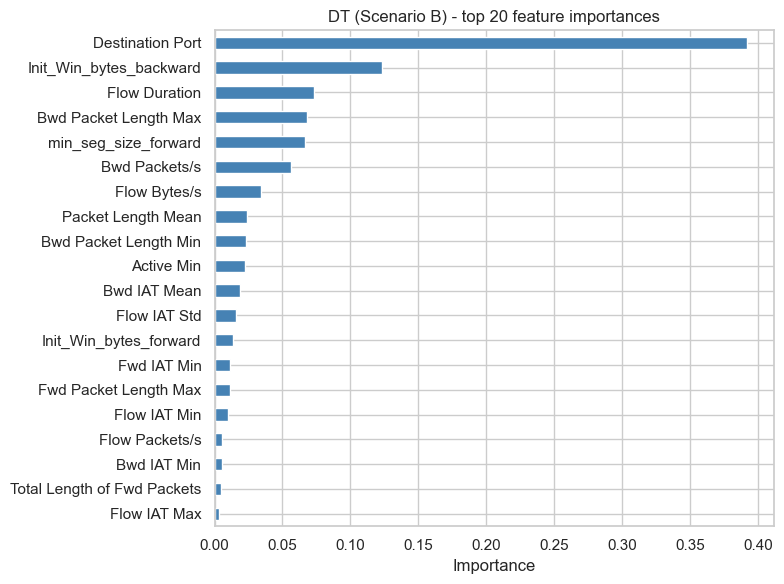

Destination Port          0.3923
Init_Win_bytes_backward   0.1229
Flow Duration             0.0734
Bwd Packet Length Max     0.0682
min_seg_size_forward      0.0663
Bwd Packets/s             0.0563
Flow Bytes/s              0.0340
Packet Length Mean        0.0238
Bwd Packet Length Min     0.0228
Active Min                0.0221
dtype: float64

In [20]:
dt_imp = plot_feature_importance(
    dt_B_search.best_estimator_, X_trainval.columns,
    top_k=20,
    title='DT (Scenario B) - top 20 feature importances',
    fname='q2_dt_feature_importance.png',
)
save_results(
    dt_imp.sort_values(ascending=False).rename('importance').reset_index().rename(columns={'index': 'feature'}),
    'q2_dt_feature_importance.csv',
)
dt_imp.sort_values(ascending=False).head(10)


### DT - Visualization του δέντρου

Δείχνουμε δύο εικόνες:

1. **Top 3 levels του actual best DT** (`max_depth_display=3`). Το πραγματικό δέντρο μπορεί να έχει `max_depth=20` ή `None` (unbounded), οπότε η πλήρης οπτικοποίηση θα ήταν αδιάβαστη. Οι top-3 levels δείχνουν τα πρώτα splits που χωρίζουν τις περισσότερες κλάσεις.
2. **Ένα ρηχό "interpretability tree"** (`max_depth=3`, fit ξεχωριστά). Πιο ακαδημαϊκό: δείχνει πώς θα έδειχνε ένα *ολόκληρο* δέντρο 3 επιπέδων - χρήσιμο για διδακτικούς λόγους.

**Πώς διαβάζεται κάθε κόμβος:**
- Πρώτη γραμμή: split rule, π.χ. `Destination Port <= 53.5`. Το left child πάει αν ισχύει, το right αν όχι.
- `entropy = ...`: impurity του κόμβου.
- `samples = ...`: αριθμός training rows που έφτασαν εκεί.
- `value = [n_class0, n_class1, ...]`: κατανομή κλάσεων (weighted).
- `class = X`: majority predicted class στον κόμβο - color-coded.

**Τι βγαίνει στην πράξη.** Το shallow tree (`max_depth=3`) καταρρέει σε **F1-weighted = 0.2489** πάνω στο test set, ενώ το best DT (Σενάριο B, `max_depth=None`) πιάνει **0.9920**. Η τεράστια αυτή διαφορά δείχνει ότι 3 επίπεδα δεν φτάνουν για να ξεχωρίσουν 15 κλάσεις με πολύ διαφορετικά signatures - το shallow tree είναι *μόνο για visualization*, όχι για χρήση ως classifier.

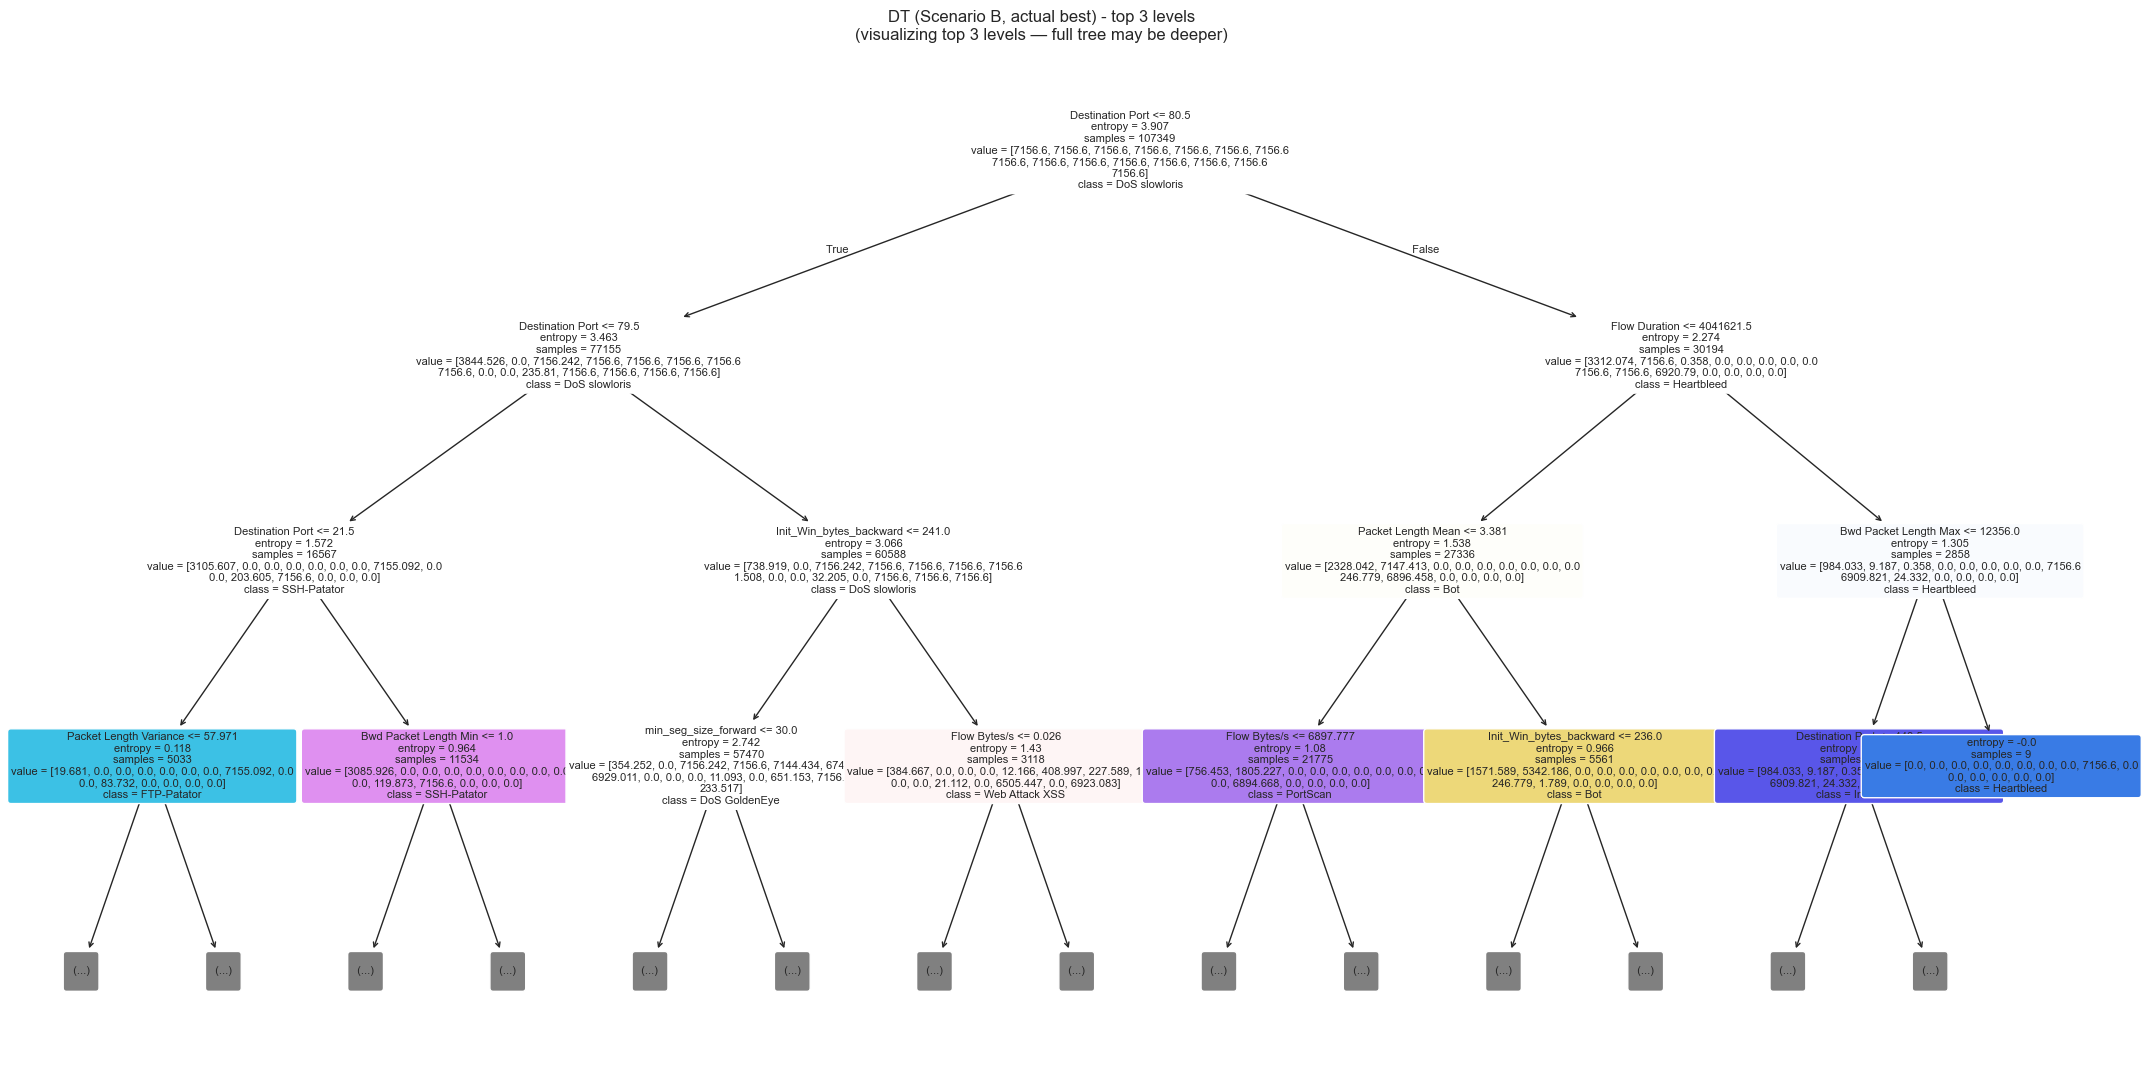

In [21]:
# 1) Top-3 levels of the actual best DT
plot_decision_tree(
    dt_B_search.best_estimator_,
    feature_names=X_trainval.columns,
    class_names=le.classes_,
    title='DT (Scenario B, actual best) - top 3 levels',
    fname='q2_dt_visualization_top3.png',
    max_depth_display=3,
)


Shallow tree (max_depth=3) test F1-weighted: 0.2489
Best DT       (Σενάριο B) test F1-weighted: 0.9920
(Το shallow είναι μόνο για visualization - δεν αντικαθιστά το best.)


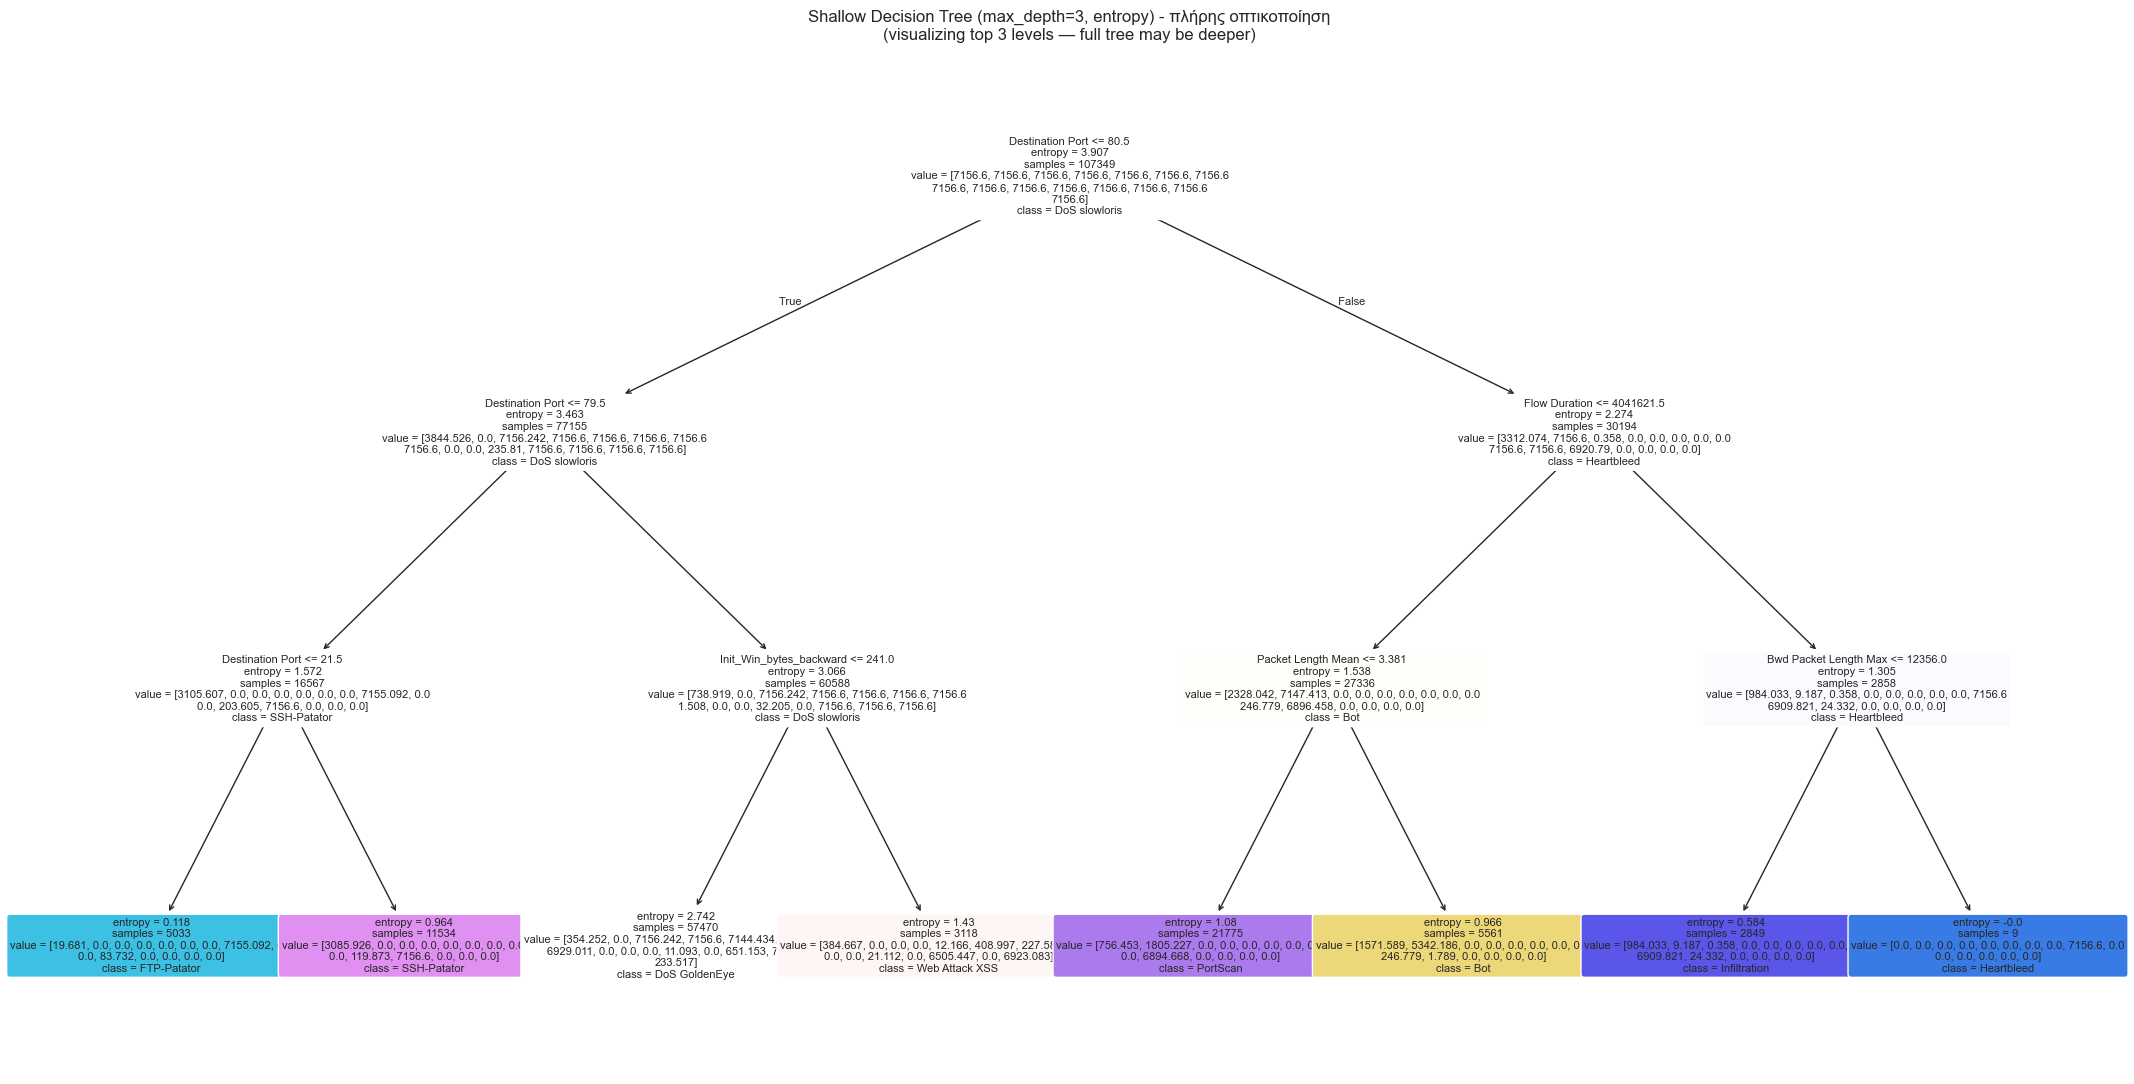

In [22]:
# 2) A separate shallow DT trained for clean visualization
dt_shallow = make_dt()
dt_shallow.set_params(max_depth=3, criterion='entropy')
dt_shallow.fit(X_trainval, y_trainval)
shallow_test_f1w = evaluate_classifier(y_test, dt_shallow.predict(X_test))['f1_weighted']
print(f'Shallow tree (max_depth=3) test F1-weighted: {shallow_test_f1w:.4f}')
print(f'Best DT       (Σενάριο B) test F1-weighted: {dt_B_metrics["f1_weighted"]:.4f}')
print('(Το shallow είναι μόνο για visualization - δεν αντικαθιστά το best.)')
plot_decision_tree(
    dt_shallow,
    feature_names=X_trainval.columns,
    class_names=le.classes_,
    title='Shallow Decision Tree (max_depth=3, entropy) - πλήρης οπτικοποίηση',
    fname='q2_dt_visualization_shallow.png',
    max_depth_display=3,
)


## 2.4 Algorithm 3 - Random Forest

**Διαίσθηση.** Ένα δέντρο είναι θορυβώδες (high variance). Ένα *δάσος* από πολλά δέντρα, αν τα δέντρα είναι αρκετά διαφορετικά μεταξύ τους, μειώνει τη variance χωρίς να αυξάνει το bias. Η ψήφος είναι majority vote (ή average των probabilities).

**Πώς εξασφαλίζει τη διαφορετικότητα των δέντρων.**
1. **Bagging** (bootstrap aggregating): κάθε δέντρο εκπαιδεύεται σε ένα bootstrap sample (random sample με replacement) του training set.
2. **Feature randomness**: σε κάθε split, το δέντρο εξετάζει μόνο ένα τυχαίο υποσύνολο features (default `sqrt(n_features)`). Έτσι, ακόμα και αν ένα feature είναι κυρίαρχο, διαφορετικά δέντρα του δάσους θα «δουν» διαφορετικές πτυχές του data.

**Γιατί συχνά χειρίζεται καλά imbalanced data.** Με `class_weight='balanced'` στο επίπεδο του δέντρου, *και* με tons of trees ψηφίζοντας, οι rare κλάσεις παίρνουν περισσότερες ευκαιρίες να αναδειχθούν. Επίσης το RF δεν υπερ-εμπιστεύεται κανένα μεμονωμένο feature.

**Δεν χρειάζεται scaling** - όπως και στο DT.

**Trade-offs.** RF είναι πιο αργό από DT (n_estimators × χρόνο 1 δέντρου), λιγότερο ερμηνεύσιμο (όχι ένα clear path απόφασης), αλλά συνήθως πιο accurate και stable.

**Hyperparameter grid (όπως ορίζει η εκφώνηση).**
- `n_estimators ∈ {50, 100, 200}` - περισσότερα δέντρα = καλύτερη μέση τιμή, αλλά diminishing returns.
- `max_depth ∈ {10, 20, None}` - όπως στο DT.
- `min_samples_split ∈ {2, 10}`.

In [23]:
RF_GRID = {
    'n_estimators'      : [50, 100, 200],
    'max_depth'         : [10, 20, None],
    'min_samples_split' : [2, 10],
}

def make_rf(n_jobs: int = -1) -> RandomForestClassifier:
    """Default n_jobs=-1 για το Σενάριο A. Στο GridSearchCV (Σενάριο B) θα
    δώσουμε n_jobs=1 ώστε να αποφύγουμε nested-parallelism oversubscription."""
    return RandomForestClassifier(
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=n_jobs,
    )

print(f'RF grid combos: {len(RF_GRID["n_estimators"]) * len(RF_GRID["max_depth"]) * len(RF_GRID["min_samples_split"])}')


RF grid combos: 18


### RF - Σενάριο A (60/20/20 split, validation-based selection)

In [24]:
t0 = time.time()
rf_A_best, rf_A_score, rf_A_grid = manual_grid_search(
    make_rf, RF_GRID, X_train, y_train, X_val, y_val,
)
save_results(rf_A_grid, 'q2_rf_grid_A.csv')
print(f'Best params (val F1-weighted = {rf_A_score:.4f}):')
for k, v in rf_A_best.items():
    print(f'  {k} = {v}')
print(f'\nGrid search time: {time.time()-t0:.1f}s')
rf_A_grid.head(10)


Best params (val F1-weighted = 0.9923):
  n_estimators = 100
  max_depth = 20
  min_samples_split = 2

Grid search time: 64.6s


,n_estimators,max_depth,min_samples_split,val_f1_weighted
0,100,20.0000,2,0.9923
1,100,NaN,2,0.9922
2,200,20.0000,2,0.9922
3,100,20.0000,10,0.9921
4,50,NaN,2,0.9921
5,50,20.0000,2,0.9921
6,200,NaN,2,0.9920
7,200,NaN,10,0.9919
8,200,20.0000,10,0.9919
9,100,NaN,10,0.9919


RF Σενάριο A - test metrics:
  accuracy      : 0.9920
  precision_w   : 0.9920
  recall_w      : 0.9920
  f1_weighted   : 0.9920
  f1_macro      : 0.9116


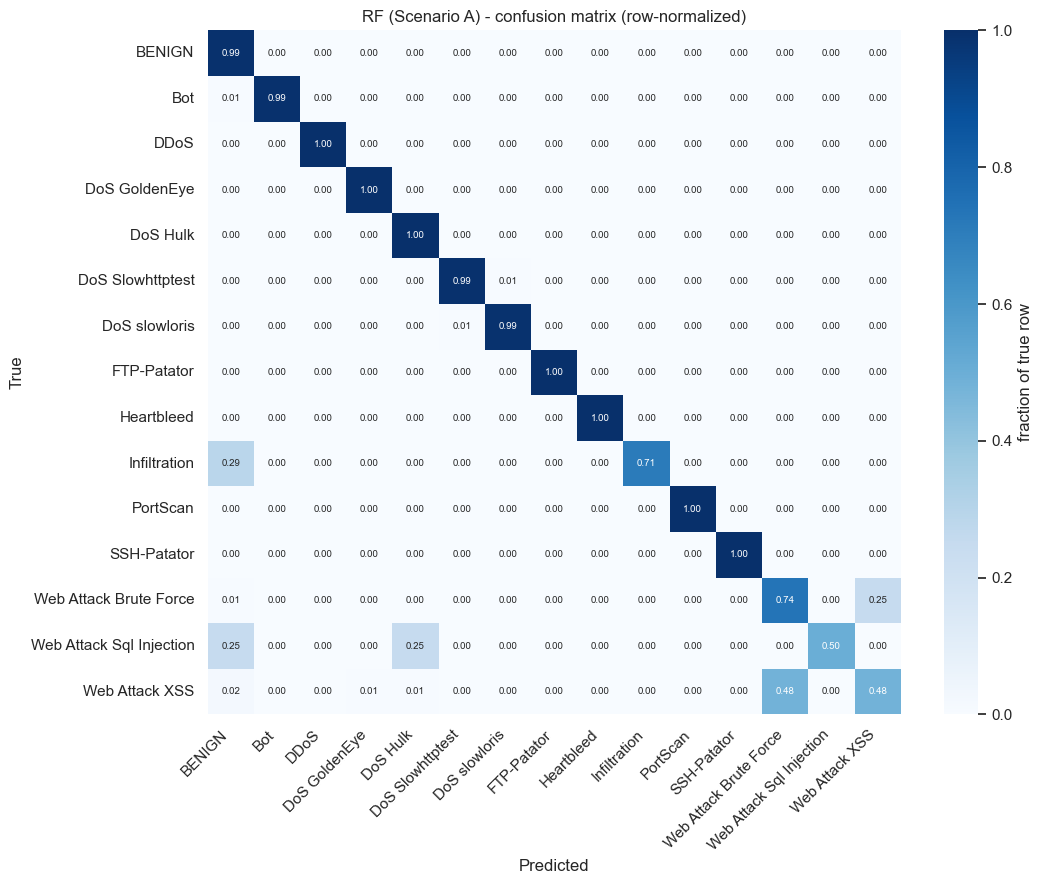

In [25]:
rf_A_final = make_rf()
rf_A_final.set_params(**rf_A_best)
rf_A_final.fit(X_trainval, y_trainval)
rf_A_pred = rf_A_final.predict(X_test)
rf_A_metrics = evaluate_classifier(y_test, rf_A_pred)
print('RF Σενάριο A - test metrics:')
for k, v in rf_A_metrics.items():
    print(f'  {k:<14}: {v:.4f}')
_ = plot_confusion(y_test, rf_A_pred, labels=list(le.classes_),
                   title='RF (Scenario A) - confusion matrix (row-normalized)',
                   fname='q2_rf_A_confusion.png')


### RF - Σενάριο B (5-fold CV)

Η πιο ακριβή σε χρόνο εκτέλεσης ενότητα του notebook. Με `n_jobs=-1` τόσο στο `GridSearchCV` όσο και στο `RandomForestClassifier` υπάρχει κίνδυνος over-subscription (πολλαπλασιαζόμενα threads). Επιλέξαμε `n_jobs=-1` *μόνο* στο `GridSearchCV` και αφήνουμε το RF μέσα του να τρέχει με τον default parallel του (που σε practice scaling-ει καλά).

In [26]:
t0 = time.time()
rf_B_search = GridSearchCV(
    estimator=make_rf(n_jobs=1),  # μέσα στη CV, αποφεύγουμε nested parallelism
    param_grid=RF_GRID,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1,
    refit=True,
)
rf_B_search.fit(X_trainval, y_trainval)
print(f'Best params (mean CV F1-weighted = {rf_B_search.best_score_:.4f}):')
for k, v in rf_B_search.best_params_.items():
    print(f'  {k} = {v}')
print(f'\nCV grid search time: {time.time()-t0:.1f}s')

rf_B_grid_df = pd.DataFrame(rf_B_search.cv_results_)[
    ['param_n_estimators','param_max_depth','param_min_samples_split',
     'mean_test_score','std_test_score','rank_test_score']
].sort_values('rank_test_score')
save_results(rf_B_grid_df.reset_index(drop=True), 'q2_rf_grid_B.csv')
rf_B_grid_df.head(10)


Best params (mean CV F1-weighted = 0.9921):
  max_depth = None
  min_samples_split = 2
  n_estimators = 100

CV grid search time: 456.0s


,param_n_estimators,param_max_depth,param_min_samples_split,mean_test_score,std_test_score,rank_test_score
13,100,None,2,0.9921,0.0006,1
12,50,None,2,0.9921,0.0006,2
7,100,20,2,0.9921,0.0007,3
14,200,None,2,0.9921,0.0007,4
6,50,20,2,0.9920,0.0008,5
16,100,None,10,0.9920,0.0006,6
17,200,None,10,0.9920,0.0007,7
8,200,20,2,0.9920,0.0008,8
15,50,None,10,0.9918,0.0006,9
10,100,20,10,0.9916,0.0008,10


RF Σενάριο B - test metrics:
  accuracy      : 0.9925
  precision_w   : 0.9920
  recall_w      : 0.9925
  f1_weighted   : 0.9921
  f1_macro      : 0.9062


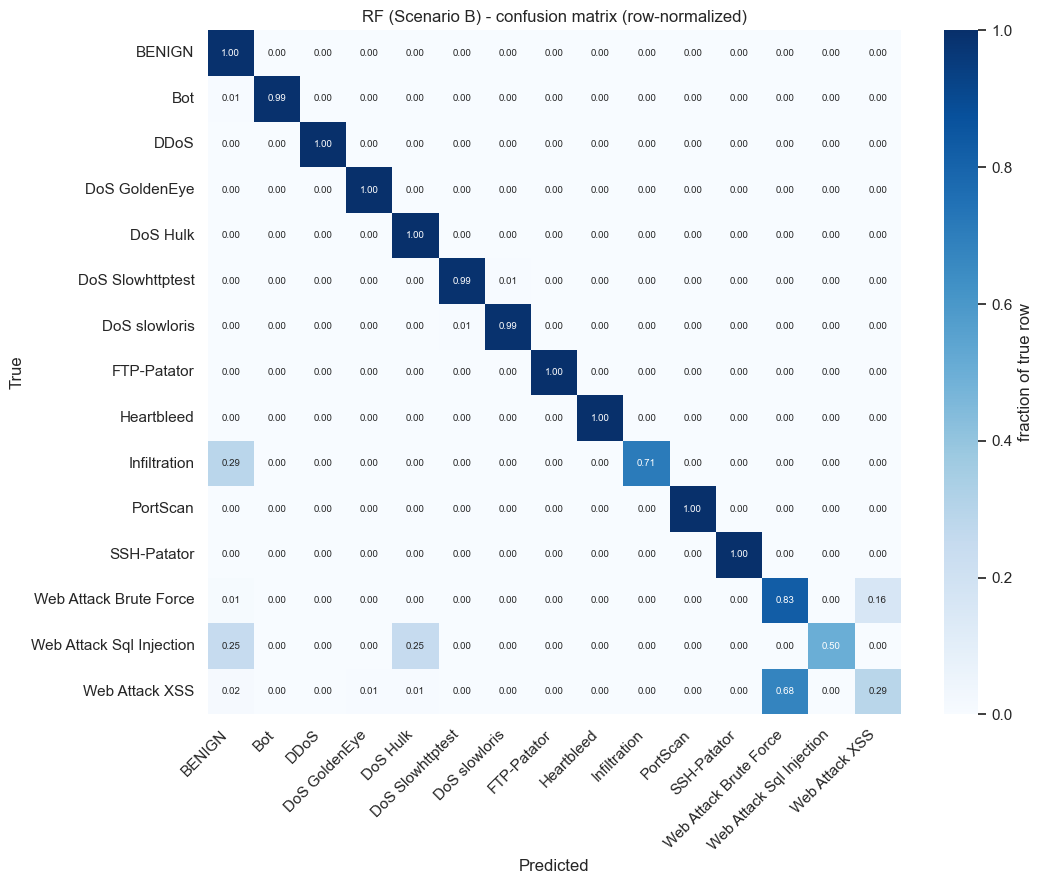

In [27]:
rf_B_pred = rf_B_search.best_estimator_.predict(X_test)
rf_B_metrics = evaluate_classifier(y_test, rf_B_pred)
print('RF Σενάριο B - test metrics:')
for k, v in rf_B_metrics.items():
    print(f'  {k:<14}: {v:.4f}')
_ = plot_confusion(y_test, rf_B_pred, labels=list(le.classes_),
                   title='RF (Scenario B) - confusion matrix (row-normalized)',
                   fname='q2_rf_B_confusion.png')


### RF - Feature importance

Στο RF, οι importances είναι ο μέσος όρος των per-tree importances. Πιο σταθερές από αυτές ενός μεμονωμένου DT, και συνήθως αναδεικνύουν τα features που πραγματικά οδηγούν την κλάση.

**Σύγκριση με το DT.** Στο DT το `Destination Port` έπαιρνε ~39% της importance μόνο του - στο RF πέφτει σε **~7.3%**, και οι top-10 features κυμαίνονται σε μια στενή ζώνη 3-7%. Είναι ακριβώς αυτό που περιμένουμε από το averaging πάνω σε 100 δέντρα με feature randomness: το signal *απλώνεται* σε περισσότερα features. Top-10 εδώ: `Destination Port` (0.073), `Init_Win_bytes_backward` (0.057), `Fwd Packet Length Max` (0.045), `Bwd Packets/s` (0.045), `Packet Length Mean` (0.041), `Bwd Packet Length Max` (0.037), `Max Packet Length` (0.036), `Flow Packets/s` (0.034), `Total Length of Fwd Packets` (0.034), `Bwd Header Length` (0.033).

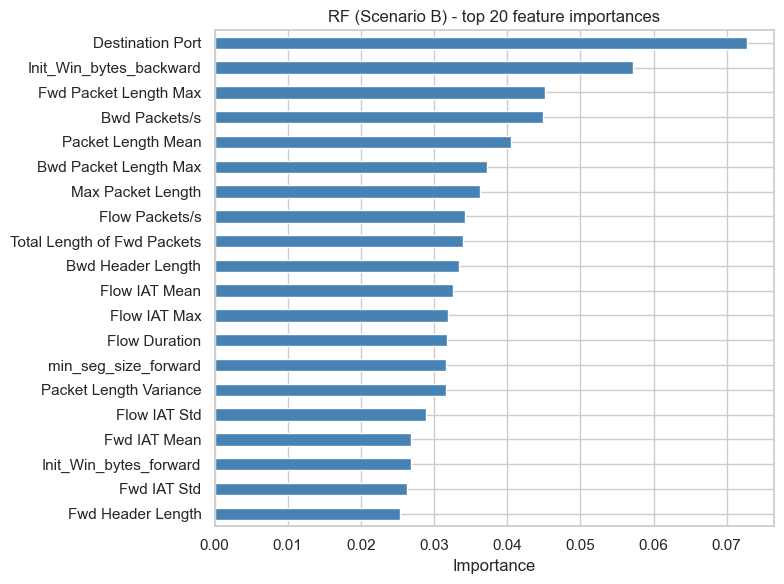

Destination Port              0.0728
Init_Win_bytes_backward       0.0571
Fwd Packet Length Max         0.0452
Bwd Packets/s                 0.0449
Packet Length Mean            0.0405
Bwd Packet Length Max         0.0372
Max Packet Length             0.0363
Flow Packets/s                0.0342
Total Length of Fwd Packets   0.0340
Bwd Header Length             0.0333
dtype: float64

In [28]:
rf_imp = plot_feature_importance(
    rf_B_search.best_estimator_, X_trainval.columns,
    top_k=20,
    title='RF (Scenario B) - top 20 feature importances',
    fname='q2_rf_feature_importance.png',
)
save_results(
    rf_imp.sort_values(ascending=False).rename('importance').reset_index().rename(columns={'index': 'feature'}),
    'q2_rf_feature_importance.csv',
)
rf_imp.sort_values(ascending=False).head(10)


### RF - Visualization ενός δέντρου από το δάσος

Δείχνουμε **ένα μόνο δέντρο** από τα 50-200 του best RF (top-3 levels). Δύο πράγματα να παρατηρήσετε:

- **Διαφορετικά splits από τον standalone DT**. Το RF tree βλέπει μόνο ένα bootstrap sample και ένα τυχαίο υποσύνολο features σε κάθε split, οπότε καταλήγει σε διαφορετική δομή. Αν οπτικοποιούσαμε ένα δεύτερο δέντρο (`tree_index=1`), η δομή θα ήταν ξανά διαφορετική. **Αυτό ακριβώς είναι το diversity που κάνει το RF να έχει χαμηλότερη variance**.
- **Η τελική RF πρόβλεψη είναι majority vote** (ή ο μέσος όρος των per-tree probabilities) πάνω σε όλα τα δέντρα. Άρα ένα μεμονωμένο δέντρο ΔΕΝ αντιπροσωπεύει την «απόφαση» του RF, παρά μόνο μία ψήφο.

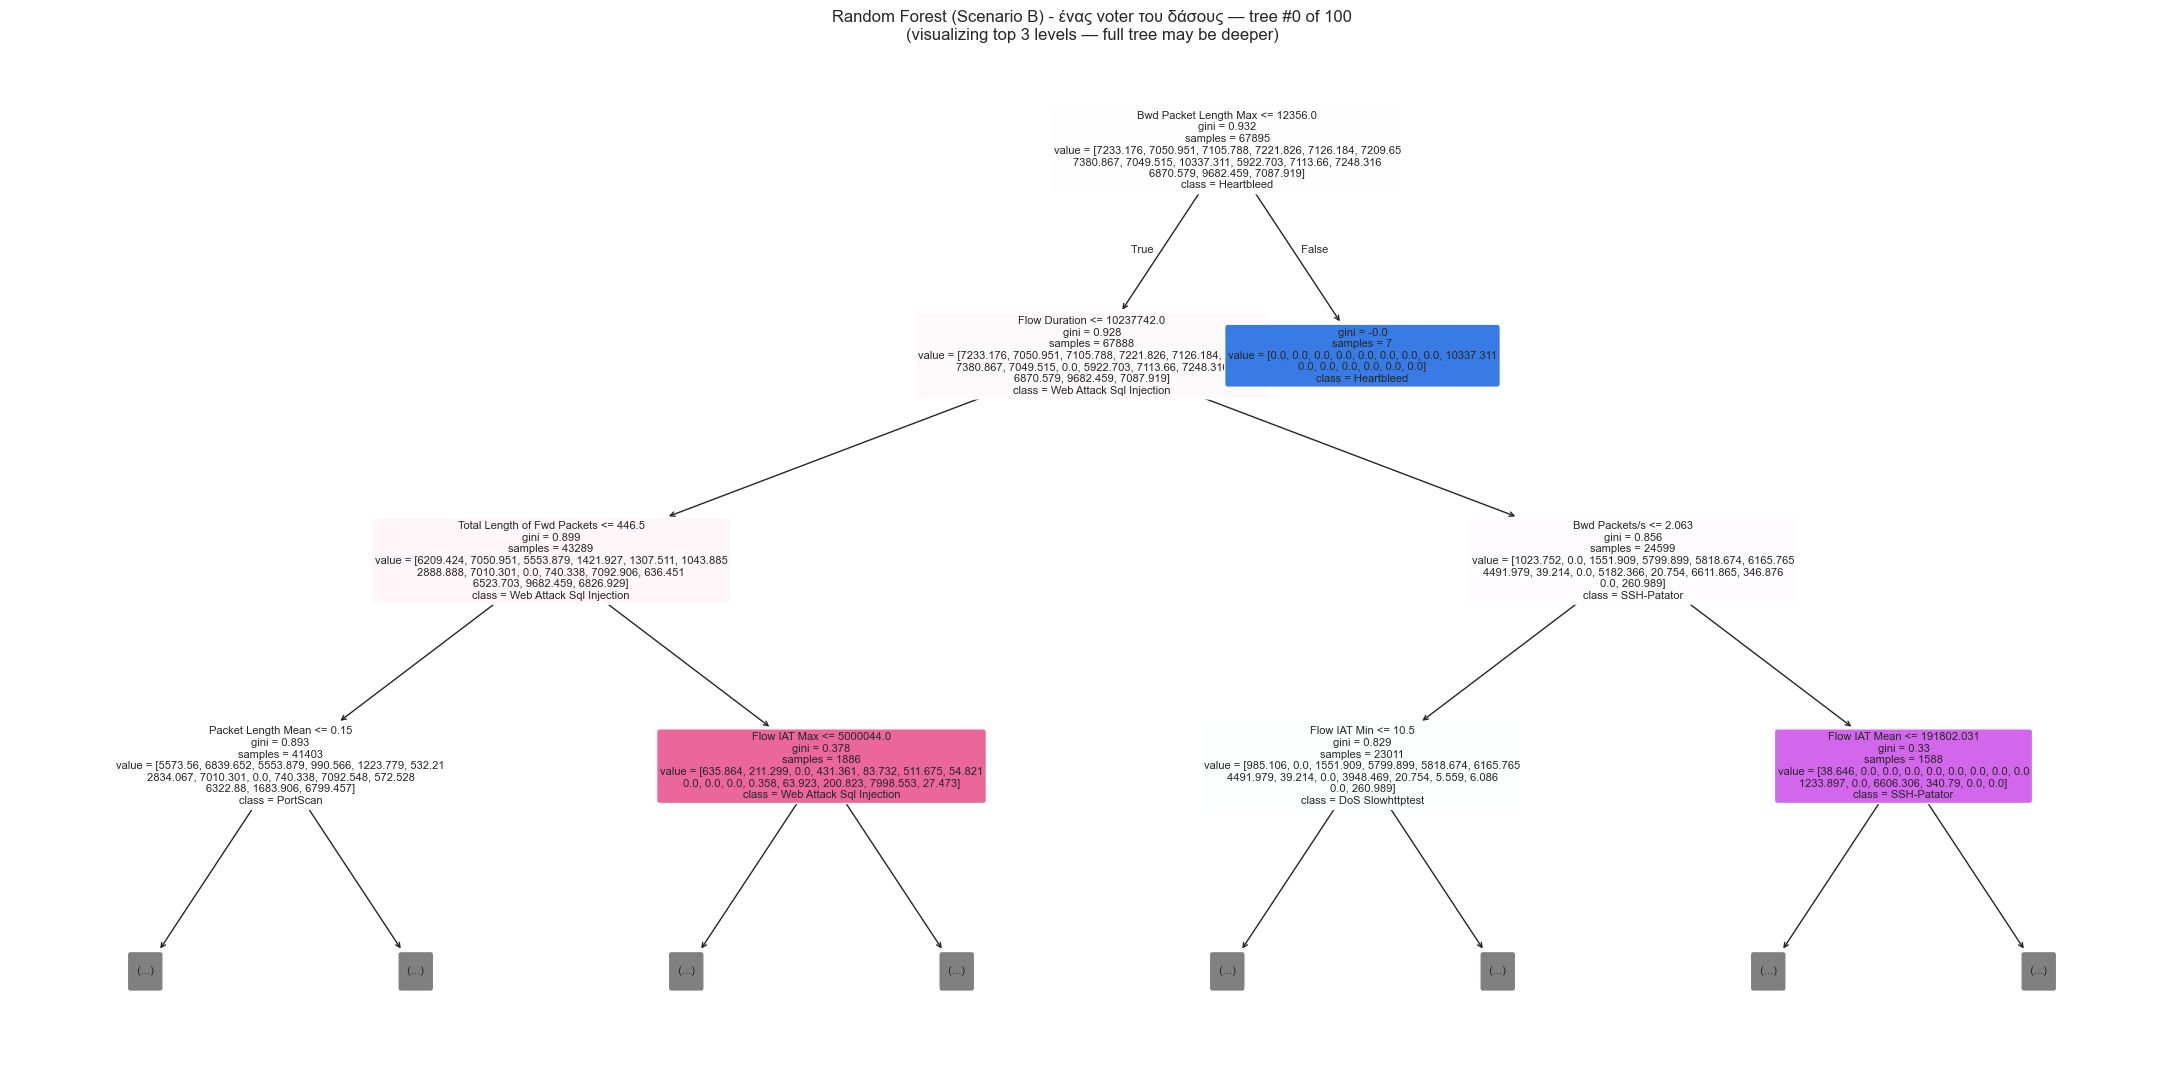

In [29]:
plot_one_forest_tree(
    rf_B_search.best_estimator_,
    tree_index=0,
    feature_names=X_trainval.columns,
    class_names=le.classes_,
    title='Random Forest (Scenario B) - ένας voter του δάσους',
    fname='q2_rf_one_tree.png',
    max_depth_display=3,
)


## 2.5 Συγκριτική ανάλυση

Συγκεντρώνουμε τα 6 αποτελέσματα (3 αλγόριθμοι × 2 σενάρια) σε έναν ενιαίο πίνακα και απαντάμε στις ερωτήσεις της εκφώνησης.

In [30]:
rows = []
def add(model, scen, metrics, best):
    rows.append({
        'model': model, 'scenario': scen,
        **{k: round(v, 4) for k, v in metrics.items()},
        'best_params': str(best),
    })

add('Logistic Regression', 'A (split)', lr_A_metrics, lr_A_best)
add('Logistic Regression', 'B (CV)'   , lr_B_metrics, lr_B_search.best_params_)
add('Decision Tree'      , 'A (split)', dt_A_metrics, dt_A_best)
add('Decision Tree'      , 'B (CV)'   , dt_B_metrics, dt_B_search.best_params_)
add('Random Forest'      , 'A (split)', rf_A_metrics, rf_A_best)
add('Random Forest'      , 'B (CV)'   , rf_B_metrics, rf_B_search.best_params_)

comparison = pd.DataFrame(rows)
save_results(comparison, 'q2_comparison_table.csv')
comparison


,model,scenario,accuracy,precision_w,recall_w,f1_weighted,f1_macro,best_params
0,Logistic Regression,A (split),0.9595,0.9750,0.9595,0.9647,0.7810,"{'algo__C': 10, 'algo__solver': 'lbfgs', 'algo..."
1,Logistic Regression,B (CV),0.9595,0.9750,0.9595,0.9647,0.7810,"{'algo__C': 10, 'algo__max_iter': 500, 'algo__..."
2,Decision Tree,A (split),0.9918,0.9930,0.9918,0.9920,0.9093,"{'max_depth': 20, 'min_samples_split': 10, 'cr..."
3,Decision Tree,B (CV),0.9921,0.9920,0.9921,0.9920,0.9097,"{'criterion': 'entropy', 'max_depth': None, 'm..."
4,Random Forest,A (split),0.9920,0.9920,0.9920,0.9920,0.9116,"{'n_estimators': 100, 'max_depth': 20, 'min_sa..."
5,Random Forest,B (CV),0.9925,0.9920,0.9925,0.9921,0.9062,"{'max_depth': None, 'min_samples_split': 2, 'n..."


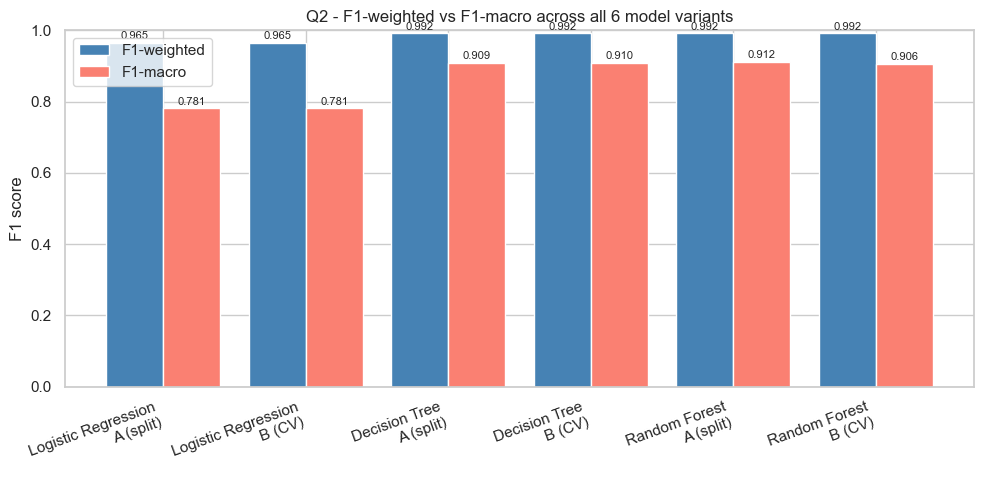

In [31]:
# Bar plot με F1-weighted και F1-macro για γρήγορο visual.
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
w = 0.4
ax.bar(x - w/2, comparison['f1_weighted'], width=w, label='F1-weighted', color='steelblue')
ax.bar(x + w/2, comparison['f1_macro'],    width=w, label='F1-macro',    color='salmon')
ax.set_xticks(x)
ax.set_xticklabels([f"{r.model}\n{r.scenario}" for r in comparison.itertuples()],
                   rotation=20, ha='right')
ax.set_ylabel('F1 score')
ax.set_ylim(0, 1.0)
ax.set_title('Q2 - F1-weighted vs F1-macro across all 6 model variants')
ax.legend()
for i, (w_, m_) in enumerate(zip(comparison['f1_weighted'], comparison['f1_macro'])):
    ax.text(i - w/2, w_ + 0.01, f'{w_:.3f}', ha='center', fontsize=8)
    ax.text(i + w/2, m_ + 0.01, f'{m_:.3f}', ha='center', fontsize=8)
plt.tight_layout()
save_figure(fig, 'q2_comparison_f1.png')
plt.show()
plt.close(fig)


### Απαντήσεις στις τέσσερις ερωτήσεις της εκφώνησης

*Τα νούμερα παρακάτω είναι από το run σε fast mode (`SUBSAMPLE_CAP=25_000`, `RANDOM_STATE=42`). Ο αναλυτικός πίνακας παραπάνω δίνει όλες τις τιμές.*

**1. Ποιος αλγόριθμος αποδίδει καλύτερα συνολικά και γιατί;**  
Στο F1-weighted τα **Decision Tree και Random Forest είναι ουσιαστικά ισόπαλα** (DT-A 0.9920, DT-B 0.9920, RF-A 0.9920, RF-B 0.9921). Στο F1-macro, το πιο σχετικό κριτήριο για imbalanced data, νικάει οριακά το **RF Σενάριο A (0.9116)**, με DT-B (0.9097), DT-A (0.9093) και RF-B (0.9062) πολύ κοντά. Ενδιαφέρον: *το RF δεν κυριάρχησε στο macro και στα δύο σενάρια* - το RF-B έμεινε πίσω από όλες τις DT/RF παραλλαγές, πιθανώς λόγω variance στις δύο-με-επτά rare-class rows ανά test set. Το **LR** μένει αρκετά πίσω: F1-weighted 0.9647, και *δραματικά* χαμηλότερο F1-macro **0.7810** - οι κλάσεις δεν είναι γραμμικά διαχωρίσιμες στον feature space, και ιδίως οι rare attacks (Heartbleed, SQL Injection, Infiltration) δεν μπορούν να κωδικοποιηθούν με ένα hyperplane. Άρα σε αυτό το dataset, DT και RF είναι πρακτικά ισοδύναμες επιλογές, με ελαφρύ προβάδισμα για RF στο macro και σαφές προβάδισμα σε όλα έναντι του LR.

**2. Δίνει το Grid Search με CV διαφορετικά hyperparameters σε σχέση με split-based;**  
Συγκρίνοντας τα `best_params`:
- **LR**: A και B καταλήγουν *ακριβώς* στα ίδια params (`C=10, solver=lbfgs, max_iter=500`) και στις ίδιες test μετρικές στο 4ο δεκαδικό. Το validation set είναι αρκετά μεγάλο (26,838 rows) ώστε η split-based επιλογή να συμφωνεί με τον CV μέσο.
- **DT**: οι best params **διαφέρουν**. A → `max_depth=20, min_samples_split=10`, B → `max_depth=None, min_samples_split=2` (κοινό `criterion=entropy`). Στο test τα F1w είναι πρακτικά ισοδύναμα (0.9920 vs 0.9920), δηλαδή οι δύο υποψήφιοι κάθονται σε ένα flat plateau όπου το single val set μπορεί τυχαία να προτιμήσει το ένα ή το άλλο.
- **RF**: οι best params **διαφέρουν** στο `max_depth`. A → `max_depth=20, n_estimators=100`, B → `max_depth=None, n_estimators=100`. Εδώ μάλιστα το A νικάει το B στο F1-macro - που δείχνει ότι η CV *δεν εγγυάται* καλύτερη επιλογή, απλώς πιο σταθερή εκτίμηση.

Συμπέρασμα: η CV είναι πιο αξιόπιστη ως ranking των combos (std τάξης 0.001 στο CV), αλλά όταν πολλά combos κάθονται σε *plateau* ~1%-3% κάτω από το peak, η διαφορά στη τελική επιλογή είναι θόρυβος.

**3. Ποιες attack types είναι οι πιο δύσκολες;**  
Από τα confusion matrices και το χαμηλό F1-macro του LR (0.78) vs το υψηλότερο των tree-based (~0.91) προκύπτει:
- **Heartbleed** (test=2), **SQL Injection** (test=4), **Infiltration** (test=7) - τόσο λίγα rows που 1 λάθος = 50%-25%-14% drop στο per-class recall. Τα tree-based τις πιάνουν συχνά (σταθερά features όπως `Destination Port`), το LR όχι - γι' αυτό πέφτει στο 0.78 macro.
- **Web Attacks (Brute Force / XSS / Sql Injection)** - συγχέονται μεταξύ τους και με BENIGN. Αναπαράγουν normal HTTP traffic με μικρές υπογραφές.
- **Bot** - μερικές φορές μπερδεύεται με BENIGN, αφού C2 traffic μιμείται HTTPS.

Οι «εύκολες» κλάσεις είναι **DDoS, DoS Hulk, PortScan, FTP-Patator, SSH-Patator** - έχουν πολύ διακριτές flow υπογραφές (rate spikes, SYN floods, αποκλίνοντα packet sizes) και πιάνονται κοντά στο 100% από όλα τα μοντέλα.

**4. Πώς επηρεάζει το class imbalance τα αποτελέσματα; (weighted vs macro F1)**  
Σε όλα τα μοντέλα το **F1-weighted > F1-macro**, όπως περιμένουμε από imbalanced data. Για τα tree-based η διαφορά είναι μικρή (~0.99 vs ~0.91, gap ~8 units), αλλά για το **LR** η διαφορά είναι τεράστια (**0.9647 vs 0.7810, gap 18 units**) - δηλώνει ότι το LR πετυχαίνει τις μεγάλες κλάσεις και αποτυγχάνει δραματικά στις rare. Το weighted τιμάει BENIGN/DDoS/DoS Hulk (83%+6.7%+5%≈95% του traffic) που όλοι οι classifier τις πιάνουν εύκολα· το macro «τιμωρείται» από Heartbleed/SQL Injection/Infiltration όπου ακόμα και 1 λάθος στα 2-7 test rows δίνει per-class F1 ~0. **Αν το τελικό IDS πρέπει να πιάσει και τις rare επιθέσεις, το macro F1 είναι το σωστό κριτήριο** και πρέπει να προτιμηθούν τα tree-based (~0.91) έναντι του LR (0.78). Αν ζυγίζουμε με traffic share (production filter), το weighted αρκεί και οποιοσδήποτε από τους τρεις classifier είναι ικανοποιητικός.